# Ring AllReduce Parameter Extraction — Statistical Evidence

Statistically validates the three claims about the realistic-model parameters, using the per-chunk timeline profiling (`nccl_allreduce_ring_inter_r-{0..3}-vary-msg-0x7.out`).

| # | Claim | Statistical method |
|---|-------|--------------------|
| 1 | `O_net` vs `nch` extracted by a recovered-bandwidth fluid model (per-chunk) | Fixed-point solve `W *= recBW/BW`; median over per-protocol steady window |
| 2 | `G_mem` (reduce bandwidth) from the union of per-chunk `T6` intervals on channel 0 | Interval-union coverage / #chunks; `G_mem = chunk_bytes / per-chunk mem time` |
| 3 | `O_round` is a real periodic drain for Simple, ~0 for LL/LL128 | One-sample t-test of `O_round_excess` vs 0, per protocol |

All statistics are hand-implemented with numpy (no scipy dependency).

In [627]:
%matplotlib inline
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---- uniform typography for ALL figures in this notebook ----
FS = 12   # single font size used everywhere (tune here)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams.update({
    'font.size': FS, 'axes.titlesize': FS, 'axes.labelsize': FS,
    'xtick.labelsize': FS, 'ytick.labelsize': FS,
    'legend.fontsize': FS, 'figure.titlesize': FS,
})

DATA_DIR = '.'
STAT = 'med'   # per-chunk statistic to use from the 100-iteration summary lines

def _pick(blob):
    """Extract chosen STAT from 'mean=.. med=.. p95=.. min=.. max=..', or a bare float (old format)."""
    m = re.search(rf'{STAT}=([-\d.]+)', blob)
    if m:
        return float(m.group(1))
    m = re.search(r'([-\d.]+)', blob)
    return float(m.group(1)) if m else 0.0

def parse_ring_file(filepath):
    with open(filepath) as f:
        content = f.read()
    cases = []
    for tc in re.split(r'#+\n# Test case:', content):
        mm = re.search(r'Message size = ([^,]+) \((\d+) bytes\)', tc)
        if not mm:
            continue
        msg_label, msg_bytes = mm.group(1), int(mm.group(2))
        rh = re.search(r'\[Rank (\d+) @ ([^\]]+)\]', tc)
        rank_id = int(rh.group(1)) if rh else None
        info = re.search(r'nranks\((\d+)\)_message_size\(\d+\)_nchannels\((\d+)\).*?_protocol\((\w+)\)', tc)
        nranks = int(info.group(1)) if info else None
        nchannels = int(info.group(2)) if info else None
        protocol = info.group(3) if info else 'unknown'
        nt = re.search(r'nthreads=(\d+)', tc); nthreads = int(nt.group(1)) if nt else None
        bf = re.search(r'buffsize=([^,]+)', tc); buffsize = bf.group(1).strip() if bf else None
        nck = re.search(r'nchunks per channel (\d+)', tc); ncpc = int(nck.group(1)) if nck else None
        # ABS_RX_DONE per chunk (recv-done absolute time; RECVDONE_TO_DR start), keyed by chunk_id
        rxdone = {int(cc): _pick(vv) for cc, vv in
                  re.findall(r'\[ABS_RX_DONE\] chunk (\d+) Irecv done\s+@ func_start \+\s*(.+?) ms', tc)}
        # ---- plugin per-rail timing (separate '--- plugin per-rail timing: channel N peer M ---'
        #      block, AFTER the send sections). Per (channel,chunk): take the LARGER rail's duration. ----
        #   A chunk's send goes over ONE rail per iteration (rail0/rail1 alternate); for small chunks the
        #   two rails are SERIAL (rail0 then rail1), so their union overcounts vs TX_TO_DONE (single-rail ping-pong).
        #   -> rail_dur = max([RAIL_DUR] rail0, [RAIL_DUR] rail1), same footprint as TX_TO_DONE. plugin = TX_TO_DONE - rail_dur.
        _rdur = {}
        for _ch, _ck, _rl, _v in re.findall(r'\[RAIL_DUR\]\s+channel (\d+) peer \d+ chunk (\d+) rail (\d+) end - start\s*:\s*(.+?) ms', tc):
            _rdur[(int(_ch), int(_ck), int(_rl))] = _pick(_v)
        def _rail_maxdur_ms(ch, cid):
            durs = [_rdur[(ch, cid, _rl)] for _rl in (0, 1)
                    if _rdur.get((ch, cid, _rl)) is not None and _rdur[(ch, cid, _rl)] > 0]
            return max(durs) if durs else None
        # send sections
        secs = re.split(r'-- --- send to peer (\d+) in channel (\d+) ---', tc)
        sends = []
        for i in range(1, len(secs), 3):
            peer, channel, section = int(secs[i]), int(secs[i+1]), secs[i+2]
            post_gap = [(c, _pick(v)) for c, v in re.findall(r'\[POST_GAP\] chunk (\d+) post gap from chunk 0:\s*(.+?) ms', section)]
            post_to_dr = [(c, _pick(v)) for c, v in re.findall(r'\[POST_TO_DR\] chunk (\d+) posted .+? data ready:\s*(.+?) ms', section)]
            dr_to_tx = [(c, _pick(v)) for c, v in re.findall(r'\[DR_TO_TX\] chunk (\d+) data ready .+? transmitted:\s*(.+?) ms', section)]
            post_to_recvdone = {int(c): _pick(v) for c, v in re.findall(r'\[POST_TO_RECVDONE\] chunk (\d+) posted .+? recv done\s*:\s*(.+?) ms', section)}
            recvdone_to_dr = {int(c): _pick(v) for c, v in re.findall(r'\[RECVDONE_TO_DR\] chunk (\d+) recv done .+? data ready\s*:\s*(.+?) ms', section)}
            # RECVDONE_TO_DR sample count per chunk (n=...); used to drop low-sample (unreliable double-peaked median) chunks
            recvdone_to_dr_n = {int(c): int(nn) for c, nn in re.findall(r'\[RECVDONE_TO_DR\] chunk (\d+) recv done .+? data ready\s*:.+? ms \(n=(\d+)\)', section)}
            tx_to_done = [(c, _pick(v)) for c, v in re.findall(r'\[TX_TO_DONE\] chunk (\d+) transmitted .+? done:\s*(.+?) ms', section)]
            atx = [(c, _pick(v)) for c, v in re.findall(r'\[ABS_TX\] chunk (\d+) transmitted @ func_start \+\s*(.+?) ms', section)]
            # gauge-computed fluid O_net / o_net_eff / k_eff (per-iter same-source median; no median-of-gap contamination).
            # O_NET / O_NET_EFF in ms; K_EFF unitless (line ends '(n=..)' not ' ms'). _pick reads med=.
            onet_g    = {int(c): _pick(v) for c, v in re.findall(r'\[O_NET\] chunk (\d+) fluid o_net .+?:\s*(.+?) ms', section)}
            oneteff_g = {int(c): _pick(v) for c, v in re.findall(r'\[O_NET_EFF\] chunk (\d+) o_net / overlap_per_ch:\s*(.+?) ms', section)}
            keff_g    = {int(c): _pick(v) for c, v in re.findall(r'\[K_EFF\] chunk (\d+) concurrency on o_net window:\s*(.+?) \(n=', section)}
            plugineff_g = {int(c): _pick(v) for c, v in re.findall(r'\[PLUGIN_EFF\] chunk (\d+) plugin .+?:\s*(.+?) ms', section)}
            othereff_g  = {int(c): _pick(v) for c, v in re.findall(r'\[OTHER_EFF\] chunk (\d+) libfabric.+?:\s*(.+?) ms', section)}
            chunks = []
            for j in range(len(post_gap)):
                cid = int(post_gap[j][0])
                chunks.append({
                    'chunk_id': cid,
                    'post_to_dr': post_to_dr[j][1] if j < len(post_to_dr) else 0,
                    'dr_to_tx': dr_to_tx[j][1] if j < len(dr_to_tx) else 0,
                    'tx_to_done': tx_to_done[j][1] if j < len(tx_to_done) else 0,
                    'post_to_recvdone': post_to_recvdone.get(cid), 'recvdone_to_dr': recvdone_to_dr.get(cid), 'recvdone_to_dr_n': recvdone_to_dr_n.get(cid),
                    'abs_tx': atx[j][1] if j < len(atx) else None,
                    'abs_rx_done': rxdone.get(cid),
                    'rail_maxdur_ms': _rail_maxdur_ms(channel, cid),
                    'onet_gauge_ms': onet_g.get(cid),        # gauge fluid O_net (ms)
                    'onet_eff_gauge_ms': oneteff_g.get(cid), # gauge o_net_eff (ms)
                    'keff_gauge': keff_g.get(cid),           # gauge k_eff on o_net window
                    'plugin_eff_gauge_ms': plugineff_g.get(cid), # gauge plugin_eff (ms; rail union)
                    'other_eff_gauge_ms': othereff_g.get(cid),   # gauge other_eff = o_net_eff - plugin_eff
                })
            sends.append({'peer': peer, 'channel': channel, 'chunks': chunks})
        cases.append({'msg_label': msg_label, 'msg_bytes': msg_bytes, 'nranks': nranks,
                      'nchannels': nchannels, 'nchunks_per_channel': ncpc, 'protocol': protocol,
                      'nthreads': nthreads, 'buffsize': buffsize,
                      'rank_id': rank_id, 'sends': sends})
    cases.sort(key=lambda c: c['msg_bytes'])
    return cases

paths = [os.path.join(DATA_DIR, f'nccl_allreduce_ring_inter_r-{r}-0x7.out') for r in range(4)]
rank0 = parse_ring_file(paths[0])   # O_net/G_mem/O_round are all measured on rank 0's send stream
print(f'Parsed rank 0: {len(rank0)} configs (using STAT={STAT!r})')

Parsed rank 0: 99 configs (using STAT='med')


In [628]:
# ---- extract O_mem (RECVDONE_TO_DR union) + O_round per config; shared helper fns for downstream cells ----
A_PPING       = 24.92                 # us, pping small-msg RTT (T_dataready_to_done)
L_US          = A_PPING / 2            # one-way latency = a/2 = 12.46 us
NIC_BW_DUAL   = 50.0 * 1e3 * 0.975    # bytes/us
NIC_BW_SINGLE = 25.0 * 1e3 * 0.975
SINGLE_EFA_THRESH = 128 * 1024
MIN_RECVDONE_TO_DR_N = 50   # drop chunks whose RECVDONE_TO_DR has <50 iteration samples (double-peaked/unreliable median)

def nic_bw(c):
    per_gpu = c['msg_bytes'] / (c['nchannels'] * c['nranks'])
    return NIC_BW_SINGLE if (c['nchannels'] == 1 and per_gpu <= SINGLE_EFA_THRESH) else NIC_BW_DUAL

def _buf_bytes(bs):
    import re as _re
    m = _re.match(r'([\d.]+)\s*([KMG]?B)', bs.strip())
    return float(m.group(1)) * {'B':1, 'KB':1024, 'MB':1024**2, 'GB':1024**3}[m.group(2)]

def chunk_bytes(c):
    # ON-WIRE bytes per chunk (used for W = chunk/BW):
    #   Simple = buffsize/4 ; LL = buffsize/8/2 (data+flag) ; LL128 = buffsize/8*15/16 (1 flag per 16)
    b = _buf_bytes(c['buffsize'])
    p = c['protocol']
    if p == 'Simple':
        return b/4
    elif p == 'LL':
        return (b/8) / 2
    else:  # LL128
        return (b/8) * 15.0/16.0

def steady(chunks):
    ids = [c['chunk_id'] for c in chunks]
    if not ids:
        return []
    nmax = max(ids)
    lo, hi = (12, 24) if nmax >= 24 else (max(3, nmax//4), nmax-1)  # steady window (chunks 12..23)
    return [c for c in chunks if lo <= c['chunk_id'] < hi]

rows = []
for c in rank0:
    if not c['sends']:
        continue
    ch = sorted(c['sends'], key=lambda s: s['channel'])[0]['chunks']
    if not steady(ch):
        continue
    cbytes = chunk_bytes(c); nic = nic_bw(c)

    # --- O_round_raw = atx[24]-atx[23] (round-boundary step) on channel 0; excess = raw - steady wire time
    atx = {x['chunk_id']: x['abs_tx'] for x in ch if x['abs_tx'] is not None}
    O_round_raw = (atx[24] - atx[23]) * 1e3 if (23 in atx and 24 in atx) else np.nan
    twire_us = cbytes * c['nchannels'] / nic          # chunk_size / (BW/nch), us

    # --- O_mem via UNION of RECVDONE_TO_DR intervals over c0..c23, per channel, averaged ---
    # each chunk's RECVDONE_TO_DR spans [abs_rx_done, abs_rx_done + RECVDONE_TO_DR]; overlapping parts counted once.
    # O_mem = union_coverage / (#chunks with RECVDONE_TO_DR)
    _omem_per_ch = []
    for _sg in c['sends']:
        ivs = []
        for x in _sg['chunks']:
            if (x['chunk_id'] < 24 and x.get('abs_rx_done') is not None and x.get('recvdone_to_dr') is not None
                    and (x.get('recvdone_to_dr_n') or 0) >= MIN_RECVDONE_TO_DR_N):
                st = x['abs_rx_done'] * 1e3
                ivs.append((st, st + x['recvdone_to_dr'] * 1e3))
        if not ivs:
            continue
        ivs.sort()
        union = 0.0; cur_s, cur_e = ivs[0]
        for st, en in ivs[1:]:
            if st > cur_e:
                union += cur_e - cur_s; cur_s, cur_e = st, en
            else:
                cur_e = max(cur_e, en)
        union += cur_e - cur_s
        _omem_per_ch.append(union / len(ivs))
    O_mem_model = float(np.mean(_omem_per_ch)) if _omem_per_ch else np.nan

    # gauge-computed fluid O_net per config = median over ALL chunks & channels (onet_gauge_ms -> us).
    # Same aggregation window as the old Python fluid (FLUID_WINDOW = all chunks), but from the
    # per-iter same-source gauge values (no median-of-gap contamination).
    _og = [x['onet_gauge_ms']*1e3 for sg in c['sends'] for x in sg['chunks']
           if x.get('onet_gauge_ms') is not None]
    O_net_gauge_us = float(np.median(_og)) if _og else np.nan
    O_net_gauge_std_us = float(np.std(_og)) if _og else np.nan

    rows.append({'protocol': c['protocol'], 'nch': c['nchannels'], 'nthreads': c['nthreads'],
                 'buffsize': c['buffsize'],
                 'O_net_gauge_us': O_net_gauge_us, 'O_net_gauge_std_us': O_net_gauge_std_us,
                 'O_mem_model_us': O_mem_model,
                 'O_round_raw_us': O_round_raw,
                 'O_round_excess_us': (O_round_raw - twire_us) if not np.isnan(O_round_raw) else np.nan})
param_df = pd.DataFrame(rows)
print(f'{len(param_df)} configs extracted (O_mem union + O_round)')
param_df.head()


99 configs extracted (O_mem union + O_round)


,protocol,nch,nthreads,buffsize,O_net_gauge_us,O_net_gauge_std_us,O_mem_model_us,O_round_raw_us,O_round_excess_us
0,LL,1,512,16KB,0.8085,0.657193,-0.36165,6.180,6.158995
1,LL,1,512,32KB,1.1690,0.465932,-0.30625,7.181,7.138990
2,LL,1,512,64KB,2.8050,0.409294,-0.65475,8.883,8.798979
3,LL,1,512,128KB,4.6510,0.218940,-3.03995,20.164,19.995959
4,LL,1,512,256KB,7.6840,0.175182,-4.02290,13.962,13.625918


In [629]:
# ---- hand-implemented statistics (no scipy) ----
from math import erf, sqrt, lgamma, exp, pi

def ols(x, y):
    """Ordinary least squares. Returns dict with intercept a, slope b, R2, std errors."""
    x = np.asarray(x, float); y = np.asarray(y, float); n = len(x)
    b, a = np.polyfit(x, y, 1)
    yh = a + b*x
    ss_res = float(np.sum((y-yh)**2)); ss_tot = float(np.sum((y-y.mean())**2))
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 1.0
    sxx = float(np.sum((x-x.mean())**2)); s2 = ss_res/(n-2) if n > 2 else 0.0
    se_b = sqrt(s2/sxx) if sxx > 0 else 0.0
    se_a = sqrt(s2*(1.0/n + x.mean()**2/sxx)) if sxx > 0 else 0.0
    return {'a': a, 'b': b, 'r2': r2, 'se_a': se_a, 'se_b': se_b, 'n': n}

def normal_cdf(z):
    return 0.5*(1+erf(z/sqrt(2)))

def welch_t(x, y):
    """Welch two-sample t-test. Returns (t, df, two-sided p via normal approx)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    mx, my = x.mean(), y.mean(); vx, vy = x.var(ddof=1), y.var(ddof=1)
    nx, ny = len(x), len(y)
    se = sqrt(vx/nx + vy/ny)
    if se == 0:
        return float('inf'), nx+ny-2, 0.0
    t = (mx-my)/se
    df = (vx/nx + vy/ny)**2 / ((vx/nx)**2/(nx-1) + (vy/ny)**2/(ny-1))
    p = 2*(1-normal_cdf(abs(t)))
    return t, df, p

def one_sample_t(x, mu=0.0):
    x = np.asarray(x, float); n = len(x)
    if n < 2:
        return float('nan'), n, float('nan')
    se = x.std(ddof=1)/sqrt(n)
    if se == 0:
        return float('inf'), n, 0.0
    t = (x.mean()-mu)/se
    p = 2*(1-normal_cdf(abs(t)))
    return t, n, p

def one_way_anova(groups):
    """F-statistic + eta^2 (effect size) for a list of arrays."""
    groups = [np.asarray(g, float) for g in groups if len(g) > 0]
    k = len(groups); N = sum(len(g) for g in groups)
    grand = np.concatenate(groups).mean()
    ss_between = sum(len(g)*(g.mean()-grand)**2 for g in groups)
    ss_within = sum(float(np.sum((g-g.mean())**2)) for g in groups)
    ss_total = ss_between + ss_within
    df_b, df_w = k-1, N-k
    F = (ss_between/df_b)/(ss_within/df_w) if (df_w > 0 and ss_within > 0) else float('inf')
    eta2 = ss_between/ss_total if ss_total > 0 else 0.0
    return {'F': F, 'df_b': df_b, 'df_w': df_w, 'eta2': eta2,
            'ss_between': ss_between, 'ss_within': ss_within}

print('stat helpers ready')

stat helpers ready


## Figure 1 — Claim 1: `O_net` vs `nch` (recovered-bandwidth fluid model)

`O_net` is extracted per chunk by a **recovered-bandwidth fixed point**, not a closed form.
Each chunk's network send occupies a W-phase `[atx, atx+W]`; the `nch` channels' chunks share the
NIC bandwidth pool (`48.75 GB/s` dual EFA, `24.375` single). Starting from `O_net=0` (`W=T7-2L`),
we compute the time-averaged concurrency `keff` over each chunk's W-window, its recovered solo
bandwidth `recBW = (chunk_bytes/W)*keff`, and shrink `W *= recBW/BW` until `recBW==BW` for all
chunks (fixed point). Then:

```
O_net = T7 - W - 2L        (2L: T7 is a send+ACK ping-pong)
```

Reported value = **median over the per-protocol steady window** (keff/W solved over ALL chunks;
windows chosen for min per-chunk std + monotone/plausible O_net-nch trend): **Simple → c3–c9,
LL → c12–c15, LL128 → c7–c11**. `chunk_bytes` on-wire: Simple=buffsize/4, LL=buffsize/8/2,
LL128=buffsize/8*15/16.

Main panel: `O_net` vs `nch` at each protocol's representative buffsize (error bars = per-chunk std
across the steady window). Per-protocol panels: `O_net` vs chunk size, one line per `nch`.


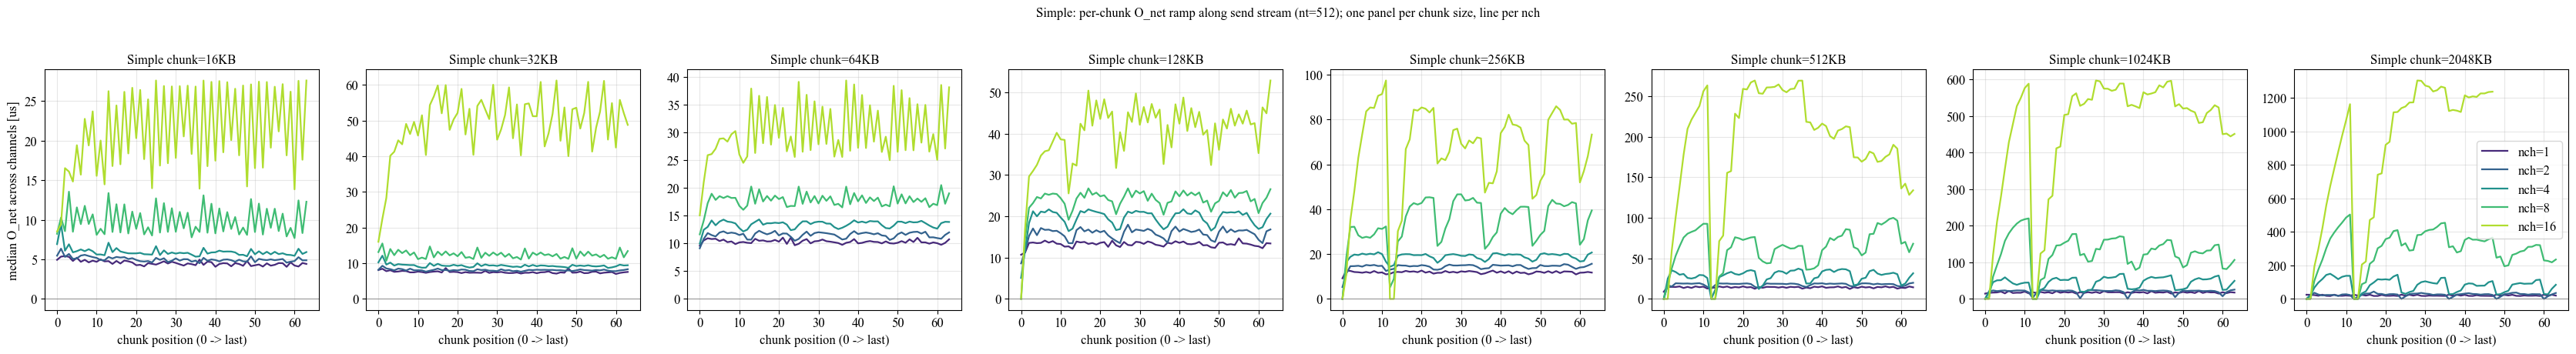

Saved: fig1b_onet_ramp_Simple.png


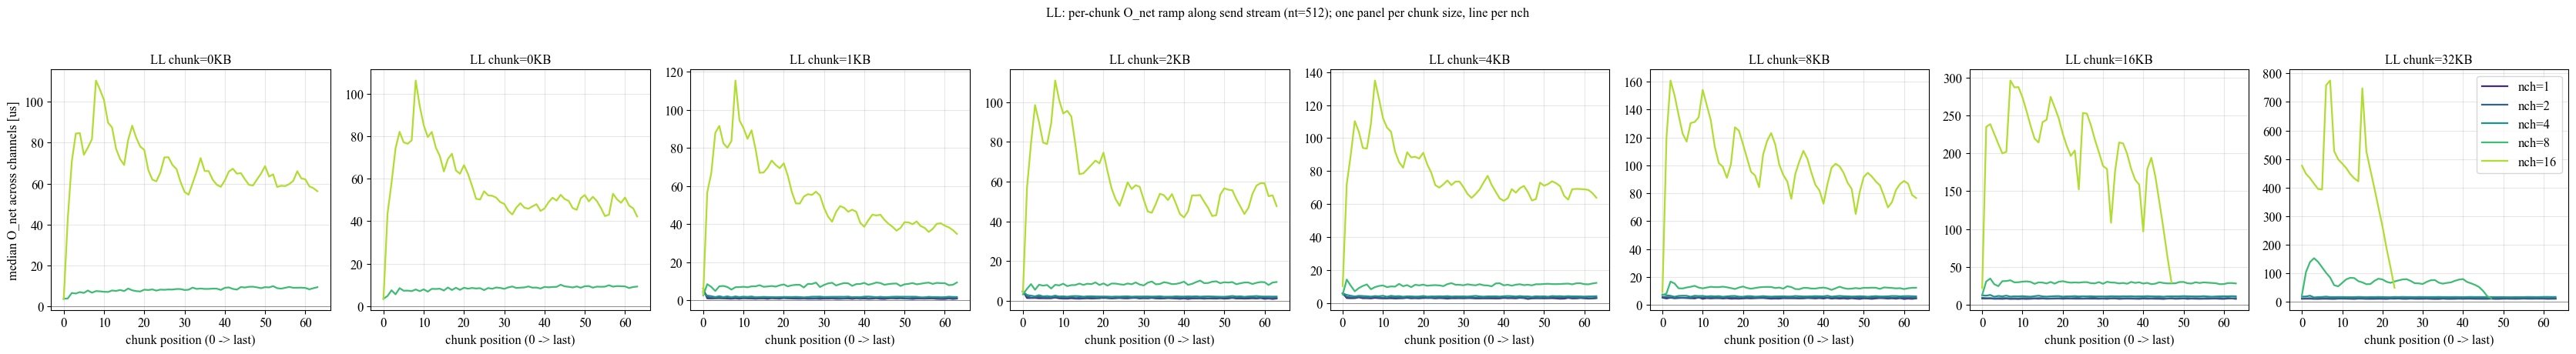

Saved: fig1b_onet_ramp_LL.png


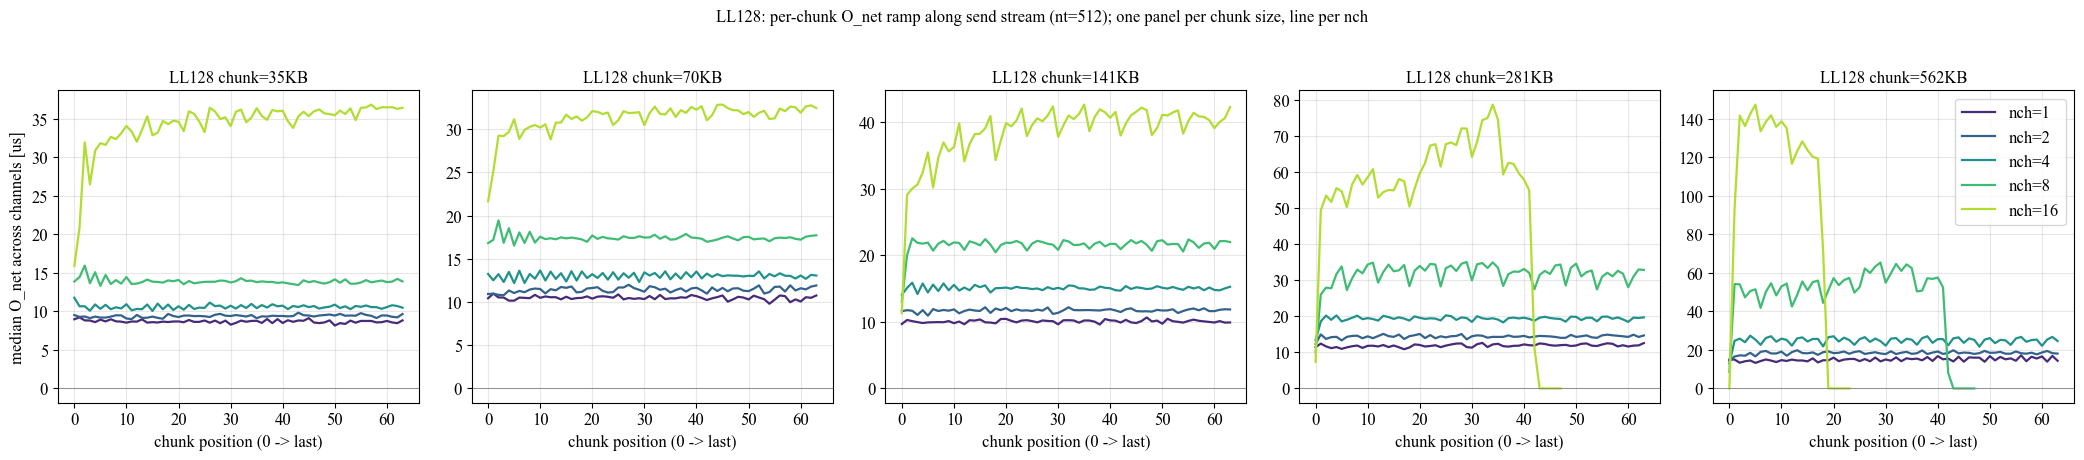

Saved: fig1b_onet_ramp_LL128.png


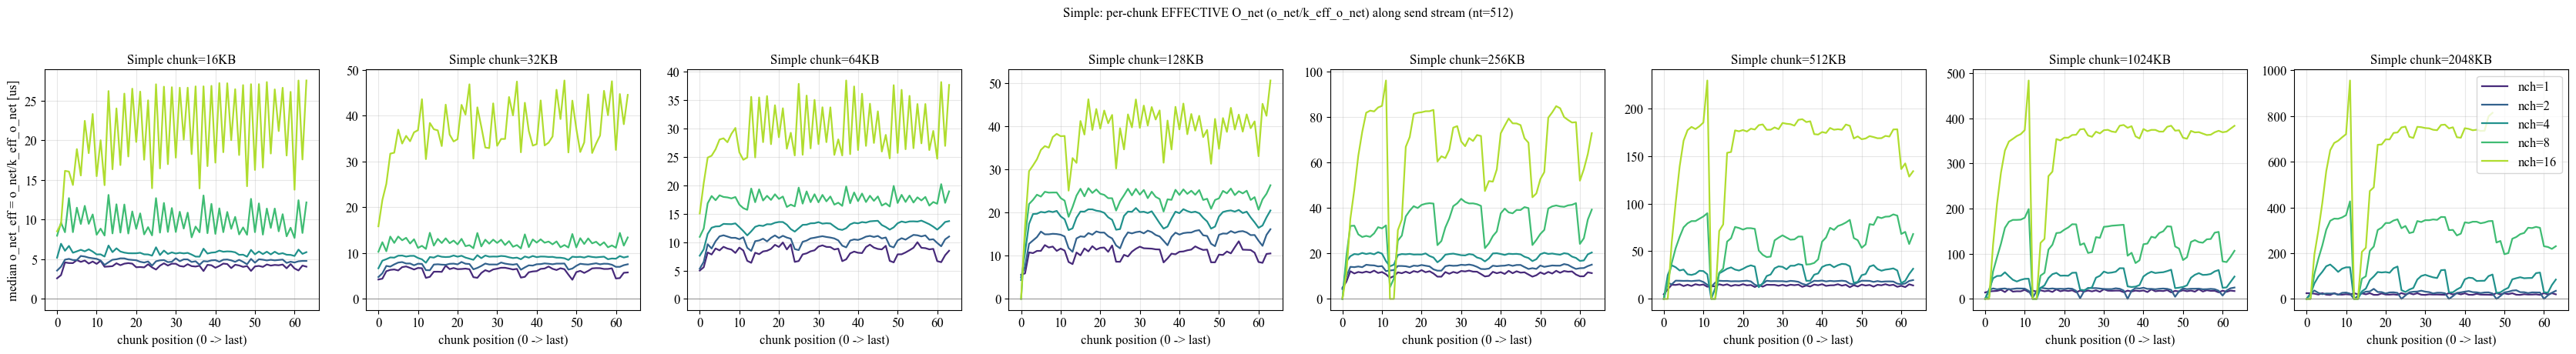

Saved: fig1c_onet_eff_Simple.png


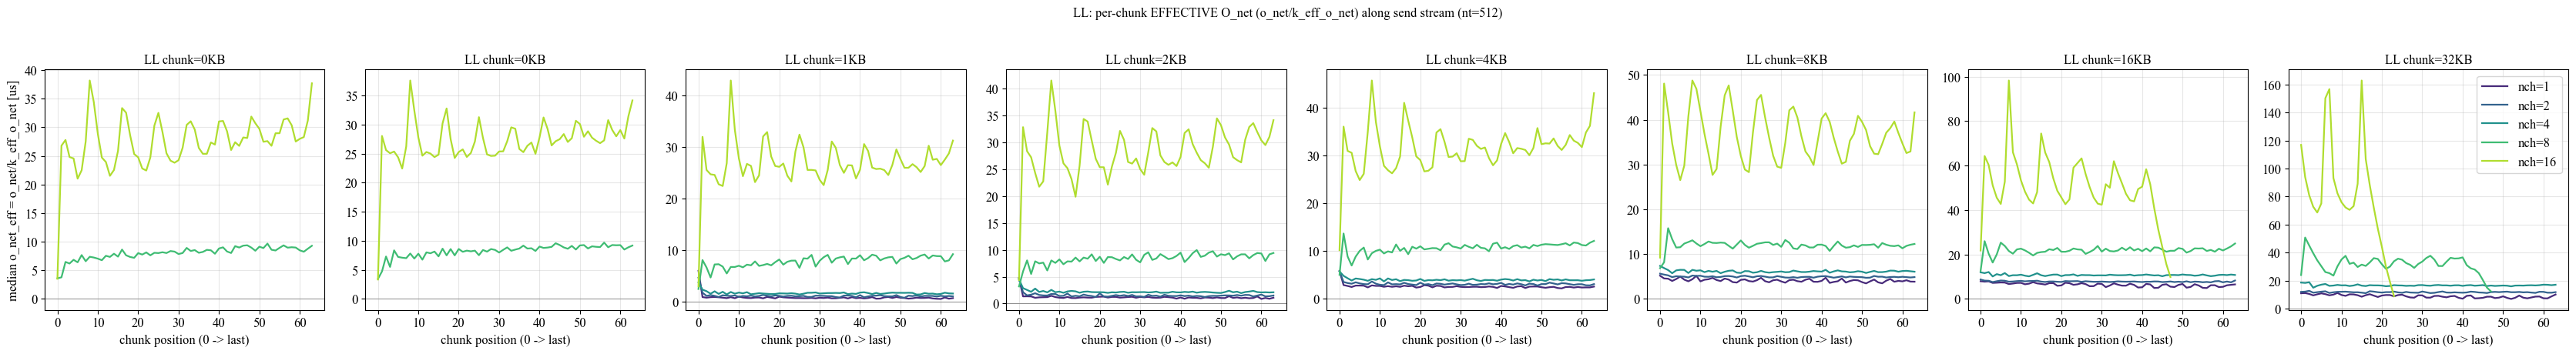

Saved: fig1c_onet_eff_LL.png


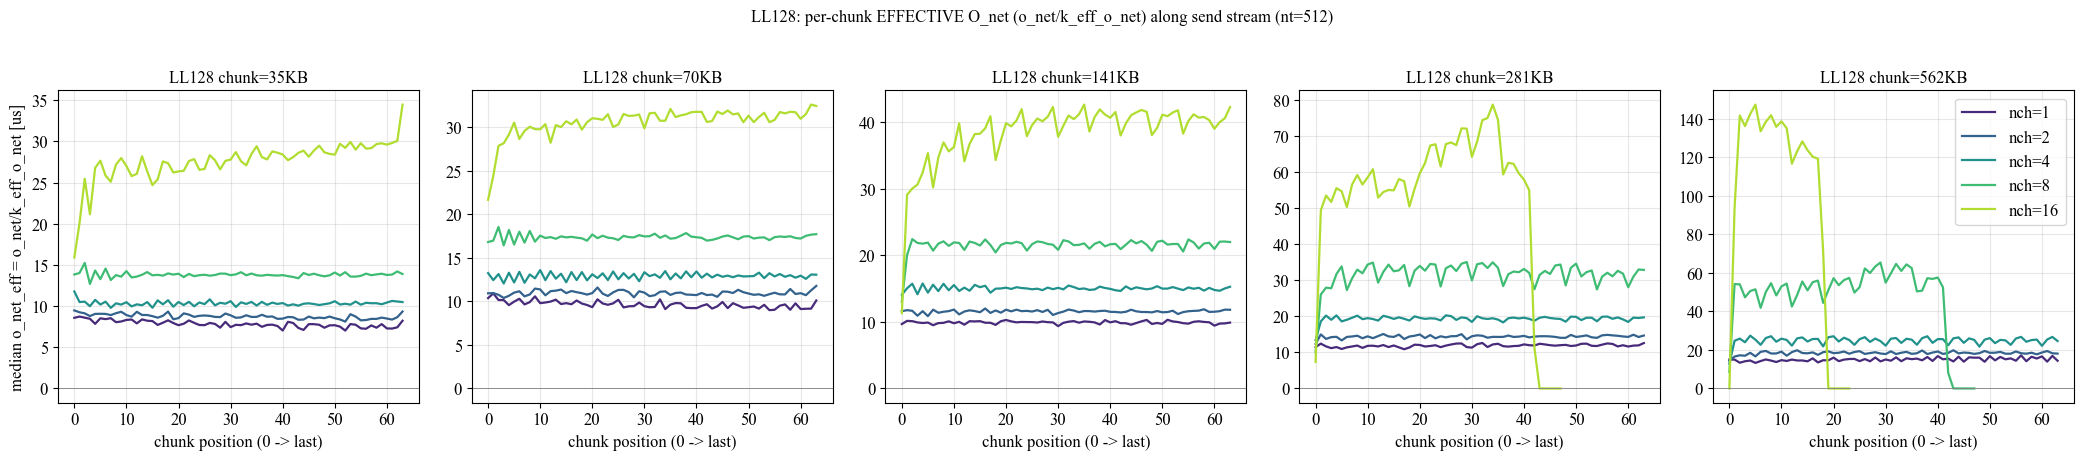

Saved: fig1c_onet_eff_LL128.png


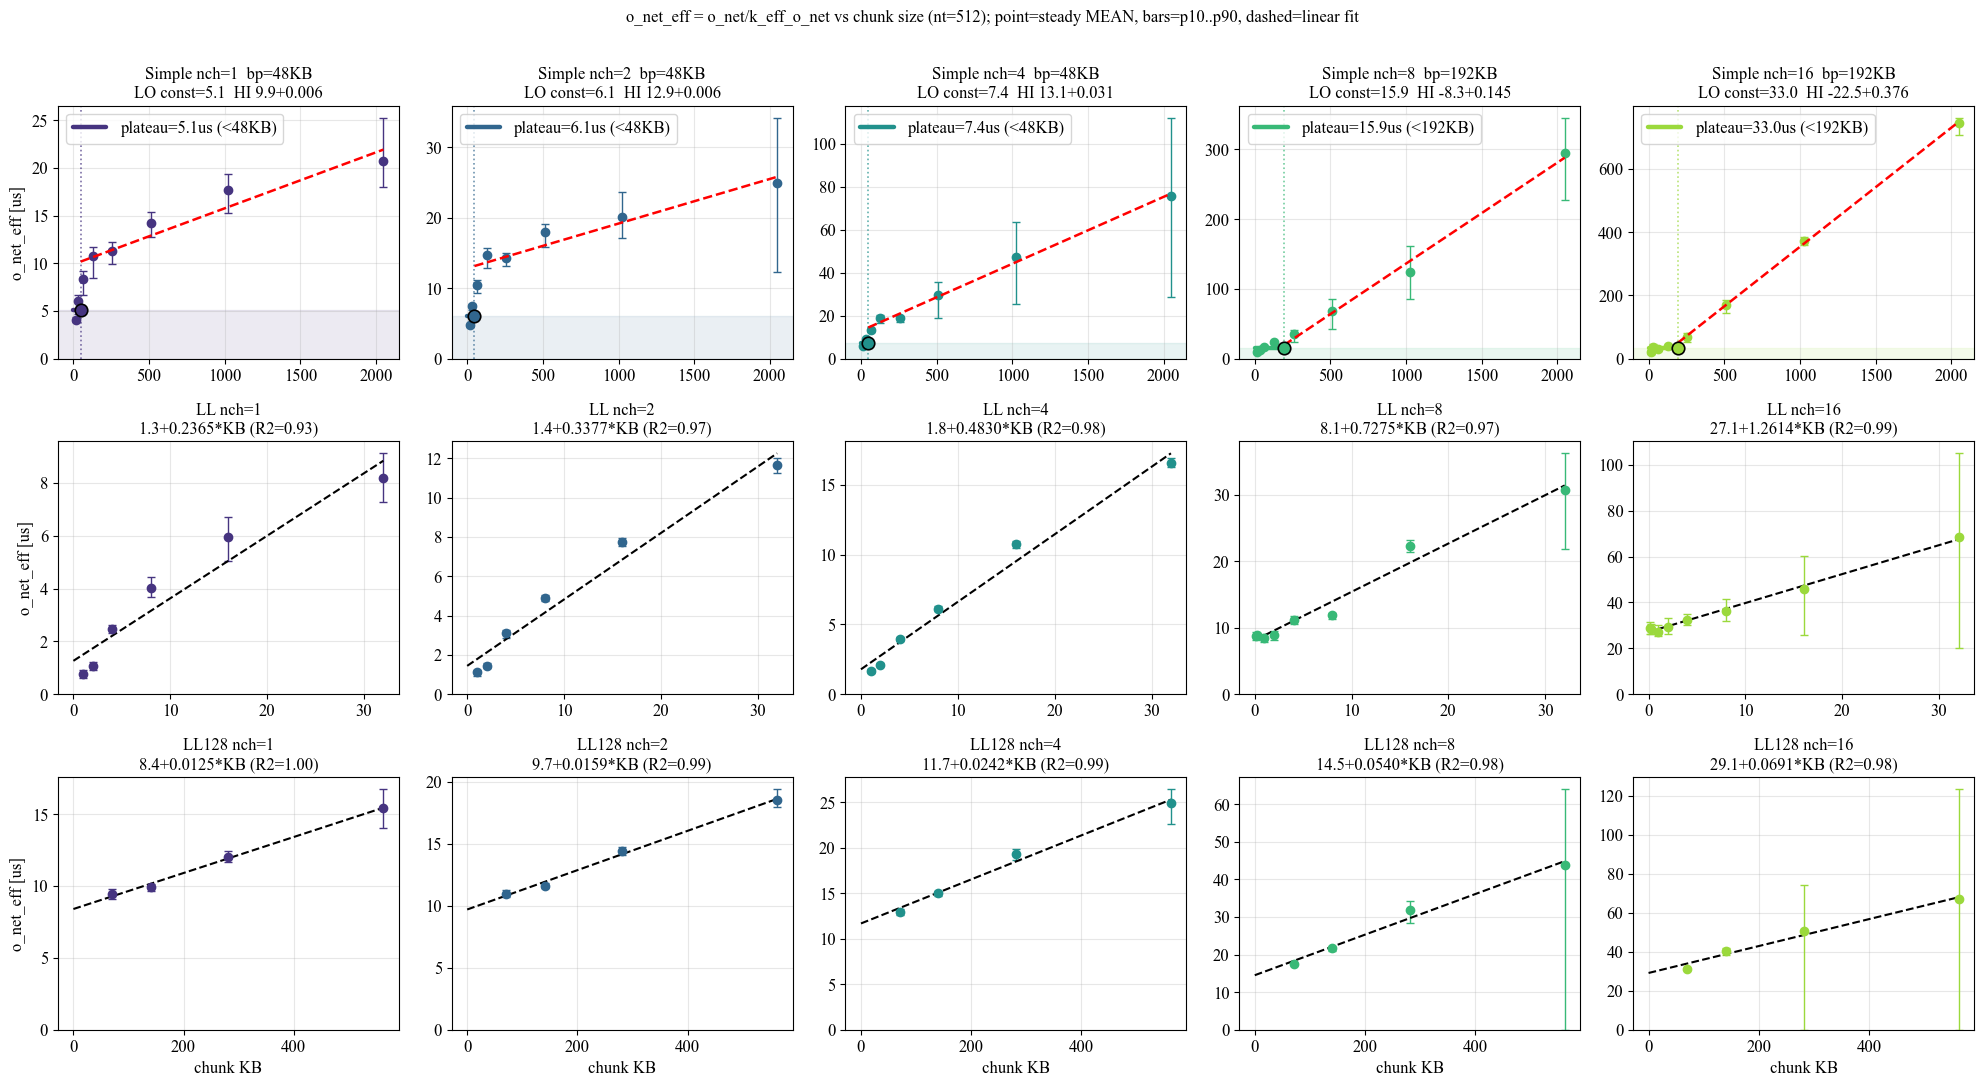

Saved: fig2_onet_eff.png
protocol  nch  chunk_KB  onet_eff_mean    p10    p90
  Simple    1      32.0           6.06   4.68   6.71
  Simple    1     256.0          11.35   9.98  12.28
  Simple    1      64.0           8.32   6.67   9.17
  Simple    1     512.0          14.20  12.75  15.34
  Simple    1    1024.0          17.71  15.32  19.33
  Simple    1     128.0          10.74   8.51  11.72
  Simple    1      16.0           4.12   3.85   4.38
  Simple    1    2048.0          20.76  18.00  25.25
  Simple    2      32.0           7.42   6.90   7.71
  Simple    2     256.0          14.27  13.20  14.99
  Simple    2      64.0          10.49   9.34  11.11
  Simple    2     512.0          17.95  15.87  19.10
  Simple    2    1024.0          20.19  17.13  23.60
  Simple    2     128.0          14.78  12.87  15.79
  Simple    2      16.0           4.79   4.58   4.98
  Simple    2    2048.0          24.97  12.38  34.18
  Simple    4      32.0           9.08   8.79   9.31
  Simple    4     256

In [630]:
import re
protos = ['Simple', 'LL', 'LL128']
colors = {'Simple': '#2E86C1', 'LL': '#E74C3C', 'LL128': '#27AE60'}
NT = 512

# fig1b (diagnostic): per-chunk O_net along the send stream, one figure per protocol.
#   Solve the fluid fixed point (all chunks coupled), then plot median O_net (across channels)
#   vs chunk POSITION (0..last). One line per (buffsize x nch) config. Shows the ramp:
#   O_net climbs from ~0 (startup), plateaus mid-stream, drops at drain -> configs without a
#   flat plateau (persistent congestion) have no single representative O_net.
# ============================================================
for _p in protos:
    _cfgs = [c for c in rank0 if c['protocol']==_p and c['nthreads']==NT]
    if not _cfgs:
        continue
    _bufs = sorted({c['buffsize'] for c in _cfgs}, key=_buf_bytes)
    _nchs = sorted({c['nchannels'] for c in _cfgs})
    fig_b, axes_b = plt.subplots(1, len(_bufs), figsize=(4.2*len(_bufs), 4.5), squeeze=False)
    axes_b = axes_b[0]
    _ncmap = {n: plt.cm.viridis(0.12 + 0.76*i/max(1,len(_nchs)-1)) for i, n in enumerate(_nchs)}
    for _bi, _buf in enumerate(_bufs):
        ax = axes_b[_bi]
        for _n in _nchs:
            _cfg = next((c for c in _cfgs if c['buffsize']==_buf and c['nchannels']==_n), None)
            if _cfg is None:
                continue
            # Use gauge-computed fluid O_net directly (per-iter same-source, no median-of-gap
            # contamination). ms -> us. Fall back to nothing if the field is absent.
            _on=[]; _cid=[]
            for _sg in _cfg['sends']:
                for _x in _sg['chunks']:
                    if _x.get('onet_gauge_ms') is not None:
                        _on.append(_x['onet_gauge_ms']*1e3); _cid.append(_x['chunk_id'])
            if len(_on) < 2:
                continue
            _on=np.array(_on); _cid=np.array(_cid)
            # median O_net per chunk_id (across channels), ordered by chunk position
            _cids = np.array(sorted(set(_cid)))
            _med = np.array([np.median(_on[_cid==cc]) for cc in _cids])
            ax.plot(np.arange(len(_cids)), _med, '-', color=_ncmap[_n], lw=1.6, label=f'nch={_n}')
        _ck = chunk_bytes(_cfg)/1024
        ax.axhline(0, color='gray', lw=0.6)
        ax.set_xlabel('chunk position (0 -> last)')
        if _bi == 0: ax.set_ylabel('median O_net across channels [us]')
        ax.set_title(f'{_p} chunk={_ck:.0f}KB')
        ax.grid(alpha=0.3)
        if _bi == len(_bufs)-1: ax.legend(fontsize=FS, ncol=1)
    fig_b.suptitle(f'{_p}: per-chunk O_net ramp along send stream (nt={NT}); one panel per chunk size, line per nch', y=1.02)
    plt.tight_layout(); plt.savefig(f'fig1b_onet_ramp_{_p}.png', dpi=140, bbox_inches='tight'); plt.show()
    print(f'Saved: fig1b_onet_ramp_{_p}.png')

# ============================================================
# fig1c (diagnostic): per-chunk EFFECTIVE O_net = o_net / k_eff_o_net.
#   Timeline of one send: tx_to_done = W + L + o_net + L, with W = S/(BW*k_eff) (fluid transfer window).
#   So the O_net segment occupies [atx + W + L, atx + W + L + o_net]. Its overhead overlaps
#   across chunks just like W does; k_eff_o_net = time-avg concurrency over that segment.
#   o_net_eff = o_net / k_eff_o_net = the part of O_net actually exposed on the critical path.
#   Plot o_net_eff vs chunk position (same layout as fig1b). Sum(o_net_eff) ~ measured net overhead.
# ============================================================
for _p in protos:
    _cfgs = [c for c in rank0 if c['protocol']==_p and c['nthreads']==NT]
    if not _cfgs:
        continue
    _bufs = sorted({c['buffsize'] for c in _cfgs}, key=_buf_bytes)
    _nchs = sorted({c['nchannels'] for c in _cfgs})
    fig_c, axes_c = plt.subplots(1, len(_bufs), figsize=(4.2*len(_bufs), 4.5), squeeze=False)
    axes_c = axes_c[0]
    _ncmap = {n: plt.cm.viridis(0.12 + 0.76*i/max(1,len(_nchs)-1)) for i, n in enumerate(_nchs)}
    for _bi, _buf in enumerate(_bufs):
        ax = axes_c[_bi]
        for _n in _nchs:
            _cfg = next((c for c in _cfgs if c['buffsize']==_buf and c['nchannels']==_n), None)
            if _cfg is None:
                continue
            # Use gauge-computed o_net_eff directly (per-iter same-source, no contamination). ms -> us.
            _onet_eff=[]; _cid=[]
            for _sg in _cfg['sends']:
                for _x in _sg['chunks']:
                    if _x.get('onet_eff_gauge_ms') is not None:
                        _onet_eff.append(_x['onet_eff_gauge_ms']*1e3); _cid.append(_x['chunk_id'])
            if len(_onet_eff) < 2:
                continue
            _onet_eff=np.array(_onet_eff); _cid=np.array(_cid)
            _cids = np.array(sorted(set(_cid)))
            _med = np.array([np.median(_onet_eff[_cid==cc]) for cc in _cids])
            ax.plot(np.arange(len(_cids)), _med, '-', color=_ncmap[_n], lw=1.6, label=f'nch={_n}')
        _ck = chunk_bytes(_cfg)/1024
        ax.axhline(0, color='gray', lw=0.6)
        ax.set_xlabel('chunk position (0 -> last)')
        if _bi == 0: ax.set_ylabel('median o_net_eff = o_net/k_eff_o_net [us]')
        ax.set_title(f'{_p} chunk={_ck:.0f}KB')
        ax.grid(alpha=0.3)
        if _bi == len(_bufs)-1: ax.legend(fontsize=FS, ncol=1)
    fig_c.suptitle(f'{_p}: per-chunk EFFECTIVE O_net (o_net/k_eff_o_net) along send stream (nt={NT})', y=1.02)
    plt.tight_layout(); plt.savefig(f'fig1c_onet_eff_{_p}.png', dpi=140, bbox_inches='tight'); plt.show()
    print(f'Saved: fig1c_onet_eff_{_p}.png')


def buf_bytes(s):
    m = re.match(r'([\d.]+)\s*([KMG]?B)', s.strip())
    return float(m.group(1)) * {'B':1, 'KB':1024, 'MB':1024**2, 'GB':1024**3}[m.group(2)]

def chunk_size_bytes(protocol, buffsize):
    # ON-WIRE bytes: Simple=buffsize/4 ; LL=buffsize/8/2 ; LL128=buffsize/8*15/16
    b = buf_bytes(buffsize)
    if protocol == 'Simple': return b/4
    elif protocol == 'LL':   return (b/8)/2
    else:                    return (b/8)*15.0/16.0

# Exclude the largest buffsize per protocol from fig1/fig2 (per user request)
EXCLUDE_BUF = {'Simple': {'16MB'}, 'LL': {'1MB'}, 'LL128': {'9600KB', '300KB'}}
d2 = param_df[(param_df.nthreads == NT)].copy()
d2 = d2[~d2.apply(lambda r: r.buffsize in EXCLUDE_BUF.get(r.protocol, set()), axis=1)]
d2['O_net'] = d2.O_net_gauge_us        # gauge fluid O_net (per-iter same-source, median over chunks)
d2['O_net_std'] = d2.O_net_gauge_std_us
d2['chunk_B'] = d2.apply(lambda r: chunk_size_bytes(r.protocol, r.buffsize), axis=1)
d2['chunk_KB'] = d2['chunk_B'] / 1024
SEL_BUF = {'Simple': '8MB', 'LL': '512KB', 'LL128': '4800KB'}
nch_all = sorted(d2.nch.unique())
nch_cmap = {n: plt.cm.viridis(0.15 + 0.7*i/max(1,len(nch_all)-1)) for i, n in enumerate(nch_all)}

# ============================================================
# fig2 (o_net_eff): 3 panels (Simple / LL / LL128). x = chunk size, y = o_net_eff,
#   one line per nch. o_net_eff = o_net / k_eff_o_net (pipeline-exposed net overhead per chunk).
#   Point = plateau median (steady chunks); error bar = p25..p75 of o_net_eff over the plateau
#   region (distribution of per-chunk o_net_eff across all chunks in steady state).
# ============================================================
def _onet_eff_per_chunk(cfg):
    """Return (chunk_ids, o_net_eff array pooled across channels) for a config."""
    # Gauge-computed o_net_eff directly (per-iter same-source). ms -> us. Pooled across channels.
    _oe=[]; _cid=[]
    for _sg in cfg['sends']:
        for _x in _sg['chunks']:
            if _x.get('onet_eff_gauge_ms') is not None:
                _oe.append(_x['onet_eff_gauge_ms']*1e3); _cid.append(_x['chunk_id'])
    if len(_oe) < 2:
        return None, None
    return np.array(_cid), np.array(_oe)

onet_eff_rows = []
onet_eff_fit_rows = []
ONET_EFF_TWOSEG = {'Simple': True, 'LL': False, 'LL128': False}  # two-segment (piecewise) o_net_eff fit; LL/LL128 use a SINGLE line (all points), Simple keeps two segments
# One subplot per (protocol x nch): rows = protocols, cols = nch. Each panel: o_net_eff vs chunk,
# points + p10..p90 bars + linear fit (o_net_eff = intercept + slope*chunk_KB).
fig, axes = plt.subplots(len(protos), len(nch_all), figsize=(4.0*len(nch_all), 3.6*len(protos)), squeeze=False)
for pi, p in enumerate(protos):
    dp_bufs = sorted({c['buffsize'] for c in rank0 if c['protocol']==p and c['nthreads']==NT}
                     & set(d2[d2.protocol==p].buffsize.unique()))
    for ni, n in enumerate(nch_all):
        ax = axes[pi][ni]
        xs=[]; ys=[]; lo=[]; hi=[]
        for buf in dp_bufs:
            cfg = next((c for c in rank0 if c['protocol']==p and c['buffsize']==buf
                        and c['nthreads']==NT and c['nchannels']==n), None)
            if cfg is None:
                continue
            cid, eff = _onet_eff_per_chunk(cfg)
            if cid is None:
                continue
            cids = np.array(sorted(set(cid)))
            curve = np.array([np.median(eff[cid==cc]) for cc in cids])
            plat_vals = curve[len(curve)//2:]        # steady half
            ck_kb = chunk_size_bytes(p, buf)/1024
            xs.append(ck_kb); ys.append(np.mean(plat_vals))
            lo.append(np.percentile(plat_vals,10)); hi.append(np.percentile(plat_vals,90))
            onet_eff_rows.append({'protocol':p,'nch':int(n),'chunk_KB':round(ck_kb,1),
                                  'onet_eff_mean':round(np.mean(plat_vals),2),
                                  'p10':round(np.percentile(plat_vals,10),2),
                                  'p90':round(np.percentile(plat_vals,90),2)})
        if xs:
            order=np.argsort(xs); xs=np.array(xs)[order]; ys=np.array(ys)[order]
            lo=np.array(lo)[order]; hi=np.array(hi)[order]
            # No exclusions: the previously-dropped LL small-chunk points are now well-behaved
            # (gauge per-iter o_net_eff), so all points are kept in the fit.
            excl = np.zeros(len(xs), dtype=bool)
            keep = ~excl
            xf, yf = xs[keep], ys[keep]
            # kept points (used in fit)
            ax.errorbar(xf, yf, yerr=[np.clip(yf-lo[keep],0,None), np.clip(hi[keep]-yf,0,None)],
                        fmt='o', color=nch_cmap[n], ms=6, capsize=3, elinewidth=1)
            # excluded points: grey hollow x
            if excl.any():
                ax.errorbar(xs[excl], ys[excl], yerr=[np.clip(ys[excl]-lo[excl],0,None), np.clip(hi[excl]-ys[excl],0,None)],
                            fmt='x', color='0.6', ms=9, mew=1.8, capsize=3, elinewidth=1, label='excluded')
                ax.legend(fontsize=FS, loc='upper left')
            # ---- PER-(proto,nch) TWO-SEGMENT fit on KEPT points (flat plateau + line) ----
            #   AUTO-SEARCH breakpoint: lo = plateau CONSTANT (mean); hi = OLS line. >=2 pts/segment.
            _two = ONET_EFF_TWOSEG.get(p, False)
            _best = None   # (sse, bp, lo_const, fh)
            if _two and len(xf) >= 4:
                for _k in range(2, len(xf)-1):
                    _bp = (xf[_k-1] + xf[_k]) / 2.0
                    _c  = float(np.mean(yf[:_k]))
                    _sse_lo = float(np.sum((yf[:_k] - _c)**2))
                    _fh = ols(xf[_k:], yf[_k:])
                    _sse_hi = float(np.sum((yf[_k:] - (_fh['a'] + _fh['b']*xf[_k:]))**2))
                    _s = _sse_lo + _sse_hi
                    if _best is None or _s < _best[0]:
                        _best = (_s, _bp, _c, _fh)
            if _best is not None:
                _sse_v, _bp, _c, _fh = _best
                _xmax = xs.max()
                # ---- plateau segment: SHADED band + bold line + join marker (high-visibility) ----
                ax.axhspan(0, _c, xmin=0, xmax=1, color=nch_cmap[n], alpha=0.10, zorder=0)  # soft fill under plateau
                ax.plot([0, _bp], [_c, _c], '-', color=nch_cmap[n], lw=3.2, solid_capstyle='round',
                        zorder=4, label=f'plateau={_c:.1f}us (<{_bp:.0f}KB)')
                ax.plot([_bp], [_c], 'o', color=nch_cmap[n], ms=9, mec='k', mew=1.2, zorder=6)  # join point
                # ---- high (line) segment: dashed red from the plateau join ----
                _xh = np.linspace(_bp, _xmax, 30)
                ax.plot(_xh, _fh['a'] + _fh['b']*_xh, '--', color='r', lw=1.8, zorder=5)
                ax.axvline(_bp, color=nch_cmap[n], ls=':', lw=1.2, alpha=0.7)
                ax.set_title(f'{p} nch={n}  bp={_bp:.0f}KB\nLO const={_c:.1f}  HI {_fh["a"]:.1f}+{_fh["b"]:.3f}', fontsize=FS)
                ax.legend(fontsize=FS, loc='upper left')
                onet_eff_fit_rows.append({'protocol':p,'nch':int(n),'breakpoint_KB':float(_bp),
                    'lo_const_us':round(_c,4),
                    'hi_intercept_us':round(_fh['a'],4),'hi_slope_us_per_KB':round(_fh['b'],6),'hi_R2':round(_fh['r2'],4)})
            elif len(xf) >= 2:
                # single line (LL128, or too few points for two segments)
                _f = ols(xf, yf); _xx = np.linspace(0, xs.max(), 50)
                ax.plot(_xx, _f['a'] + _f['b']*_xx, '--', color='k', lw=1.5)
                ax.set_title(f'{p} nch={n}\n{_f["a"]:.1f}+{_f["b"]:.4f}*KB (R2={_f["r2"]:.2f})', fontsize=FS)
                onet_eff_fit_rows.append({'protocol':p,'nch':int(n),'breakpoint_KB':None,
                    'lo_const_us':None,
                    'hi_intercept_us':round(_f['a'],4),'hi_slope_us_per_KB':round(_f['b'],6),'hi_R2':round(_f['r2'],4)})
        ax.axhline(0, color='gray', lw=0.5); ax.set_ylim(0, None); ax.grid(alpha=0.3)
        if pi==len(protos)-1: ax.set_xlabel('chunk KB')
        if ni==0: ax.set_ylabel('o_net_eff [us]')
fig.suptitle(f'o_net_eff = o_net/k_eff_o_net vs chunk size (nt={NT}); point=steady MEAN, bars=p10..p90, dashed=linear fit', y=1.005)
plt.tight_layout(); plt.savefig('fig2_onet_eff.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig2_onet_eff.png')
print(pd.DataFrame(onet_eff_rows).to_string(index=False))
print('\nLinear fit  o_net_eff = intercept + slope*chunk_KB  (per proto,nch):')
print(pd.DataFrame(onet_eff_fit_rows).to_string(index=False))
print(f'(excluded buffsizes: {EXCLUDE_BUF})')
print('Per-protocol panels: solid lines = measured anchors + linear interp (== realistic O_NET_ANCHORS lookup).')


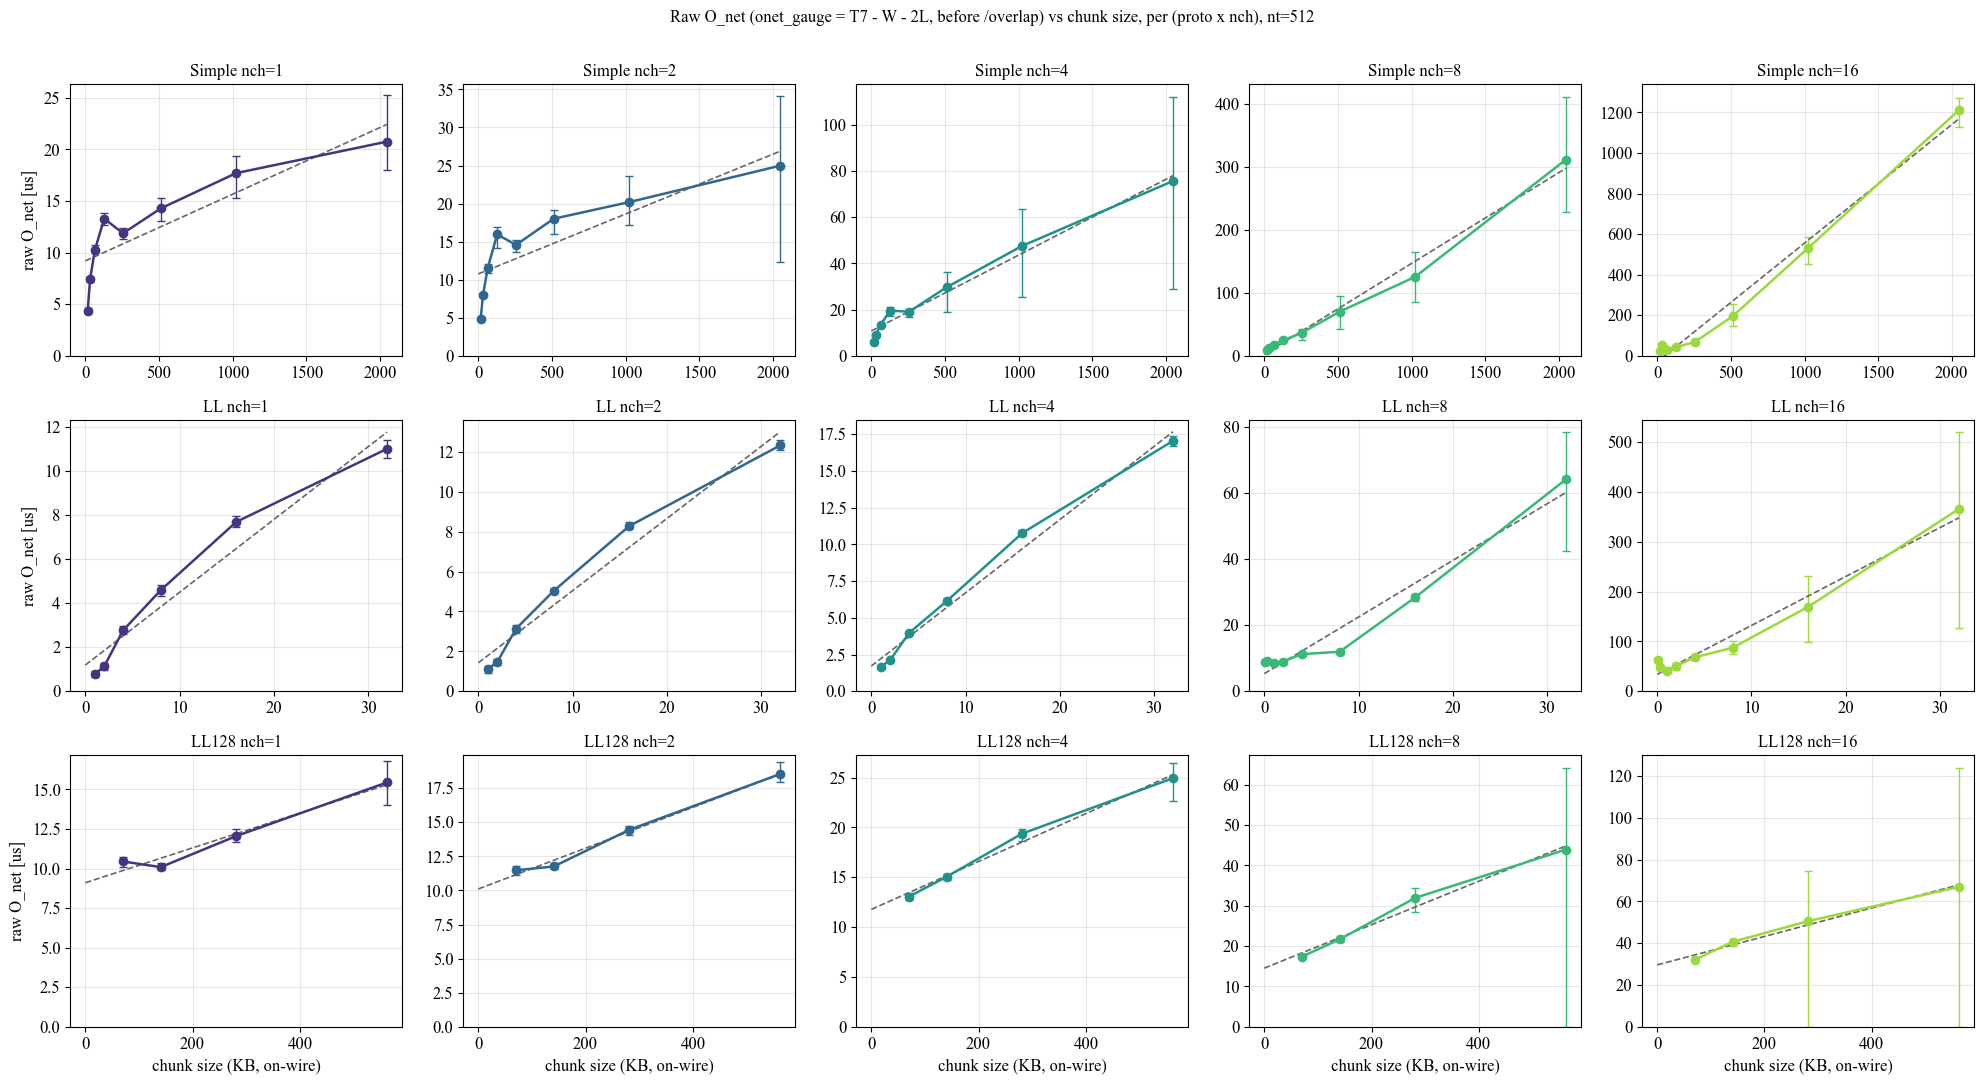

Saved: fig2b_onet_raw.png


In [631]:
# ==== Grid: RAW O_net (onet_gauge = T7 - W - 2L, NOT concurrency-divided) vs chunk size ====
# Same layout as fig2_onet_eff: rows = protocol (Simple/LL/LL128), cols = nch (1/2/4/8/16).
# Each panel: raw O_net vs chunk size (one point per buffsize), points + p10..p90 bars.
# (fig2 plots o_net_eff = O_net/overlap_per_ch; this plots the RAW O_net before that division.)
onet_raw_fit_rows = []
def _onet_raw_per_chunk(cfg):
    """Per-chunk raw O_net (us) for a config, pooled across channels: onet_gauge_ms * 1e3."""
    _cid=[]; _on=[]
    for _sg in cfg['sends']:
        for _x in _sg['chunks']:
            v = _x.get('onet_gauge_ms')
            if v is not None:
                _cid.append(_x['chunk_id']); _on.append(v*1e3)
    if len(_cid) < 1:
        return None, None
    return np.array(_cid), np.array(_on)

fig_r, axes_r = plt.subplots(len(protos), len(nch_all), figsize=(4.0*len(nch_all), 3.6*len(protos)), squeeze=False)
for pi, p in enumerate(protos):
    dp_bufs = sorted({c['buffsize'] for c in rank0 if c['protocol']==p and c['nthreads']==NT}
                     & set(d2[d2.protocol==p].buffsize.unique()))
    for ni, n in enumerate(nch_all):
        ax = axes_r[pi][ni]
        xs=[]; ys=[]; lo=[]; hi=[]
        for buf in dp_bufs:
            cfg = next((c for c in rank0 if c['protocol']==p and c['buffsize']==buf
                        and c['nthreads']==NT and c['nchannels']==n), None)
            if cfg is None:
                continue
            cid, on = _onet_raw_per_chunk(cfg)
            if cid is None:
                continue
            cids = np.array(sorted(set(cid)))
            curve = np.array([np.median(on[cid==cc]) for cc in cids])
            plat_vals = curve[len(curve)//2:]                 # steady half
            ck_kb = chunk_size_bytes(p, buf)/1024
            xs.append(ck_kb); ys.append(np.mean(plat_vals))
            lo.append(np.percentile(plat_vals,10)); hi.append(np.percentile(plat_vals,90))
        if xs:
            order=np.argsort(xs); xs=np.array(xs)[order]; ys=np.array(ys)[order]
            lo=np.array(lo)[order]; hi=np.array(hi)[order]
            ax.errorbar(xs, ys, yerr=[np.clip(ys-lo,0,None), np.clip(hi-ys,0,None)],
                        fmt='o-', color=nch_cmap[n], ms=6, lw=1.8, capsize=3, elinewidth=1)
            # single-line OLS fit of RAW O_net vs chunk_KB (used as the FIFO-hiding threshold in realistic)
            if len(xs) >= 2:
                _fr = ols(xs, ys)
                onet_raw_fit_rows.append({'protocol':p,'nch':int(n),
                    'intercept_us':round(_fr['a'],4),'slope_us_per_KB':round(_fr['b'],6),'R2':round(_fr['r2'],4)})
                _xx=np.linspace(0,xs.max(),50); ax.plot(_xx,_fr['a']+_fr['b']*_xx,'--',color='0.4',lw=1.2)
            ax.set_title(f'{p} nch={n}', fontsize=FS)
        else:
            ax.set_title(f'{p} nch={n} (no data)', fontsize=FS)
        ax.grid(alpha=0.3); ax.set_ylim(0, None)
        if ni==0: ax.set_ylabel('raw O_net [us]', fontsize=FS)
        if pi==len(protos)-1: ax.set_xlabel('chunk size (KB, on-wire)', fontsize=FS)
fig_r.suptitle('Raw O_net (onet_gauge = T7 - W - 2L, before /overlap) vs chunk size, per (proto x nch), nt=512',
               fontsize=FS, y=1.002)
plt.tight_layout(); plt.savefig('fig2b_onet_raw.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig2b_onet_raw.png')


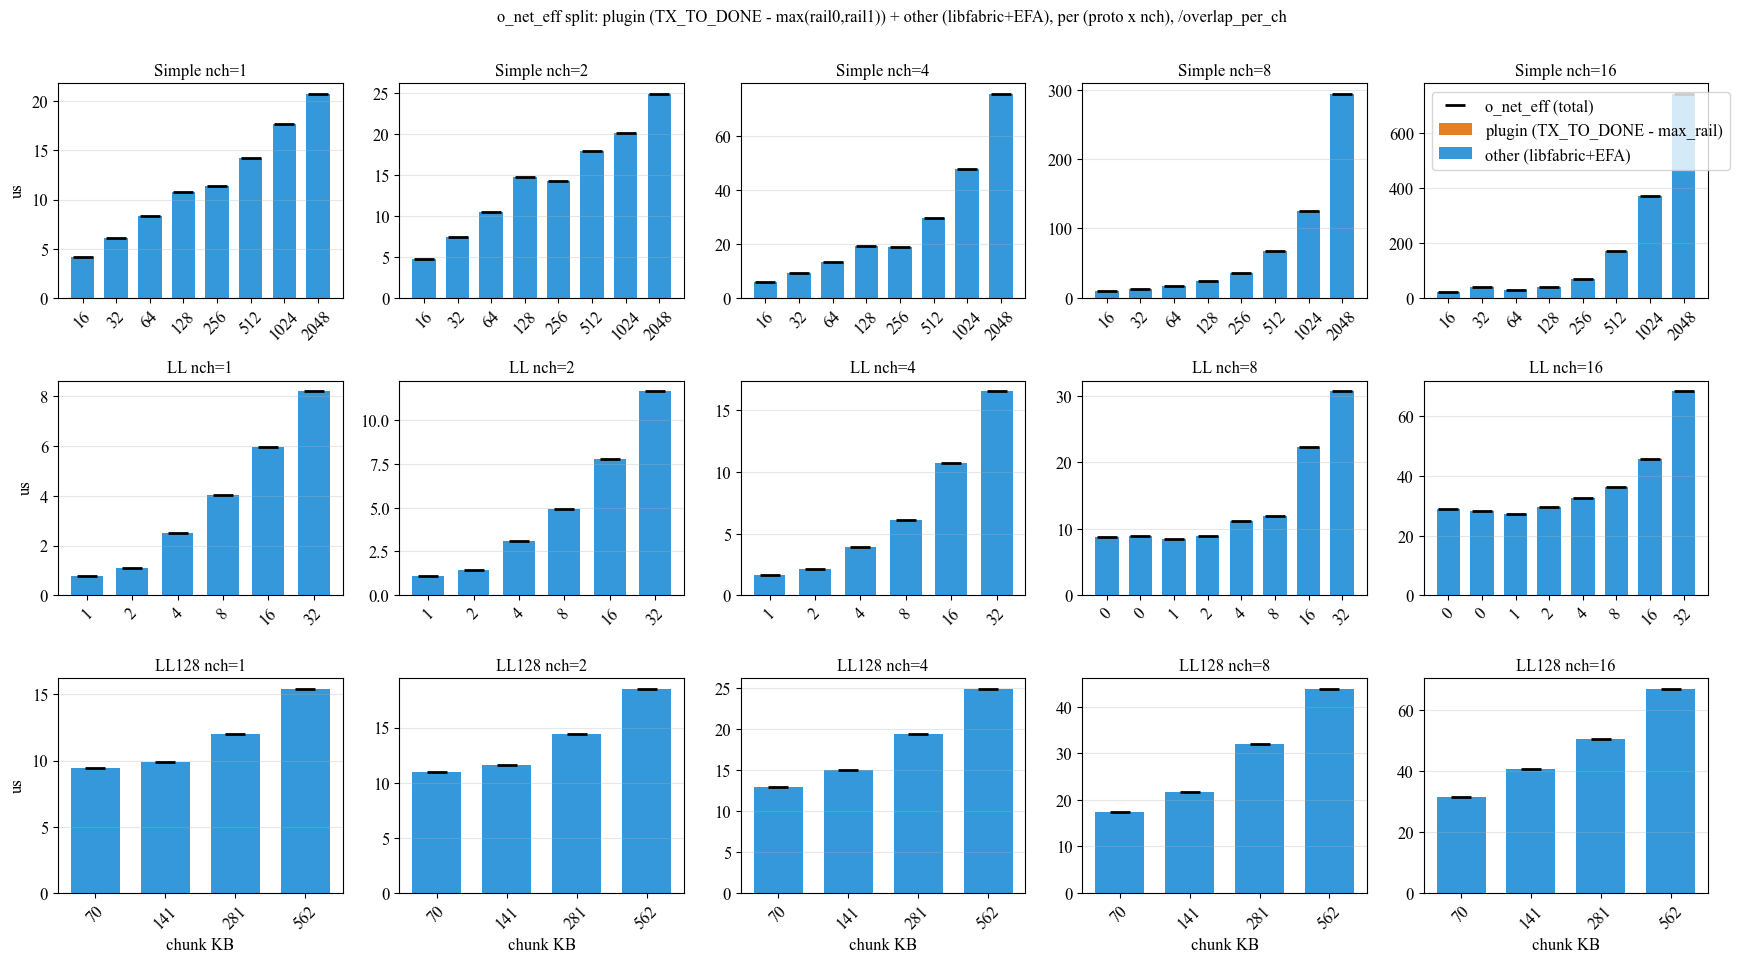

Saved: fig1_onet_eff_plugin_split.png
protocol  nch  chunk_KB  onet_eff  plugin_eff  other_eff
  Simple    1     32.00      6.06         0.0       6.06
  Simple    1    256.00     11.35         0.0      11.35
  Simple    1     64.00      8.32         0.0       8.32
  Simple    1    512.00     14.20         0.0      14.20
  Simple    1   1024.00     17.71         0.0      17.71
  Simple    1    128.00     10.74         0.0      10.74
  Simple    1     16.00      4.12         0.0       4.12
  Simple    1   2048.00     20.76         0.0      20.76
  Simple    2     32.00      7.42         0.0       7.42
  Simple    2    256.00     14.27         0.0      14.27
  Simple    2     64.00     10.49         0.0      10.49
  Simple    2    512.00     17.95         0.0      17.95
  Simple    2   1024.00     20.19         0.0      20.19
  Simple    2    128.00     14.78         0.0      14.78
  Simple    2     16.00      4.79         0.0       4.79
  Simple    2   2048.00     24.97         0.0     

In [632]:
# ==== Claim 1 addendum: split o_net_eff into (plugin) + (other = libfabric+EFA) ====
# Hypothesis: TX_TO_DONE = W + 2L + o_net_eff, where o_net_eff bundles plugin + libfabric + EFA overhead.
#   plugin (per chunk)  = TX_TO_DONE - max(rail0_dur, rail1_dur)    [rail_maxdur_ms parsed from raw file]
#   plugin_eff          = plugin / overlap_per_ch          [same concurrency divisor as o_net_eff]
#   other_eff           = o_net_eff - plugin_eff           [libfabric + EFA network layer]
# Analysis only -- NOT exported to ring_params.json. Stacked bars: plugin (bottom) + other (top).
def _split_per_chunk(cfg):
    """Return (chunk_ids, o_net_eff, plugin_eff) pooled across channels for one config.
    All from the gauge (per-iter same-source; no median-of-gap contamination):
      o_net_eff   = onet_eff_gauge_ms * 1e3           (us)
      overlap_pc  = max(keff_gauge / nch, 1)          (gauge k_eff on the O_net window)
      plugin      = TX_TO_DONE - (rail0 UNION rail1) (us, from gauge)
      plugin_eff  = plugin / overlap_pc               (same concurrency divisor as o_net_eff)"""
    # All from the gauge (per-iter same-source, rail UNION-based plugin; no contamination):
    #   o_net_eff = onet_eff_gauge_ms*1e3 ; plugin_eff = plugin_eff_gauge_ms*1e3 (rail0∪rail1). us.
    _cid=[]; _oe=[]; _plug_eff=[]
    for _sg in cfg['sends']:
        for _x in _sg['chunks']:
            oe = _x.get('onet_eff_gauge_ms'); pe = _x.get('plugin_eff_gauge_ms')
            if oe is None or pe is None:
                continue
            _cid.append(_x['chunk_id'])
            _oe.append(oe * 1e3)          # ms -> us
            _plug_eff.append(pe * 1e3)    # ms -> us  (gauge plugin_eff, rail union)
    if len(_cid) < 2:
        return None, None, None
    return np.array(_cid), np.array(_oe), np.array(_plug_eff)

# Collect steady-window mean per (proto, nch, chunk_size), same steady window as fig2 (upper half of chunk_ids)
_split_rows=[]
for p in protos:
    dp_bufs = sorted({c['buffsize'] for c in rank0 if c['protocol']==p and c['nthreads']==NT}
                     & set(d2[d2.protocol==p].buffsize.unique()))
    for n in nch_all:
        for buf in dp_bufs:
            cfg = next((c for c in rank0 if c['protocol']==p and c['buffsize']==buf
                        and c['nthreads']==NT and c['nchannels']==n), None)
            if cfg is None: continue
            cid, eff, plug = _split_per_chunk(cfg)
            if cid is None: continue
            cids = np.array(sorted(set(cid)))
            eff_c  = np.array([np.median(eff[cid==cc]) for cc in cids])
            plug_c = np.array([np.nanmedian(plug[cid==cc]) if np.any(~np.isnan(plug[cid==cc])) else np.nan for cc in cids])
            half = slice(len(cids)//2, None)                       # steady half
            eff_m  = float(np.mean(eff_c[half]))
            plug_m = float(np.nanmean(plug_c[half])) if np.any(~np.isnan(plug_c[half])) else np.nan
            if abs(eff_m) < 1e-6:              # o_net_eff ~ 0 -> no measurable overhead: zero both parts
                plug_m = 0.0; other_m = 0.0
            else:
                other_m = eff_m - plug_m
            _split_rows.append({'protocol':p,'nch':int(n),'chunk_KB':chunk_size_bytes(p,buf)/1024,
                                'onet_eff':eff_m,'plugin_eff':plug_m,'other_eff':other_m})

# ---- Stacked bar chart: one subplot per (proto x nch); x = chunk_KB; stack = plugin (bottom) + other (top) ----
_sr = pd.DataFrame(_split_rows)
if len(_sr) == 0:
    print('No PLUGIN_EFF/OTHER_EFF in data (gauge needs recompile+rerun for the union split). Skipping fig1_onet_eff_plugin_split.')
else:
  fig, axes = plt.subplots(len(protos), len(nch_all), figsize=(3.6*len(nch_all), 3.2*len(protos)), squeeze=False)
  for pi, p in enumerate(protos):
      for ni, n in enumerate(nch_all):
          ax = axes[pi][ni]
          d = _sr[(_sr.protocol==p) & (_sr.nch==n)].sort_values('chunk_KB')
          if len(d)==0:
              ax.axis('off'); continue
          x = np.arange(len(d)); labels=[f'{c:.0f}' for c in d.chunk_KB]
          plug = np.clip(d.plugin_eff.values, 0, None)      # clip negatives to 0 for the stack view
          other = np.clip(d.other_eff.values, 0, None)
          ax.bar(x, plug,  width=0.7, color='#E67E22', label='plugin (TX_TO_DONE - max_rail)')
          ax.bar(x, other, width=0.7, bottom=plug, color='#3498DB', label='other (libfabric+EFA)')
          # overlay actual o_net_eff as a marker (may differ from stack when plugin<0 clipped)
          ax.plot(x, d.onet_eff.values, 'k_', ms=14, mew=2, label='o_net_eff (total)')
          ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=FS, rotation=45)
          ax.set_title(f'{p} nch={n}', fontsize=FS)
          if ni==0: ax.set_ylabel('us', fontsize=FS)
          if pi==len(protos)-1: ax.set_xlabel('chunk KB', fontsize=FS)
          ax.grid(axis='y', alpha=0.3)
          if pi==0 and ni==len(nch_all)-1: ax.legend(fontsize=FS, loc='upper left')
  fig.suptitle('o_net_eff split: plugin (TX_TO_DONE - max(rail0,rail1)) + other (libfabric+EFA), per (proto x nch), /overlap_per_ch',
               fontsize=FS, y=1.002)
  plt.tight_layout(); plt.savefig('fig1_onet_eff_plugin_split.png', dpi=140, bbox_inches='tight'); plt.show()
  print('Saved: fig1_onet_eff_plugin_split.png')
  print(_sr.round(2).to_string(index=False))


## Figure 2 — Claim 2: `O_mem` (= T6, recv done -> data ready) vs nthreads and vs chunk size

`O_mem` is the reduce step time, measured directly as `T6`. Two panels:

- **Left:** `O_mem` vs number of threads (one line per protocol/chunk size). For Simple/LL the reduce
  is thread-bound: slow at 64 threads, plateaus at >=256. For LL128, `T6` is flag/sync, ~flat in nthreads.
- **Right:** `O_mem` vs chunk size (one line per protocol, nthreads fixed). `O_mem` rises with chunk
  size — for Simple this is the memory-bandwidth-bound reduce (`O_mem = chunk_size / G_mem`).

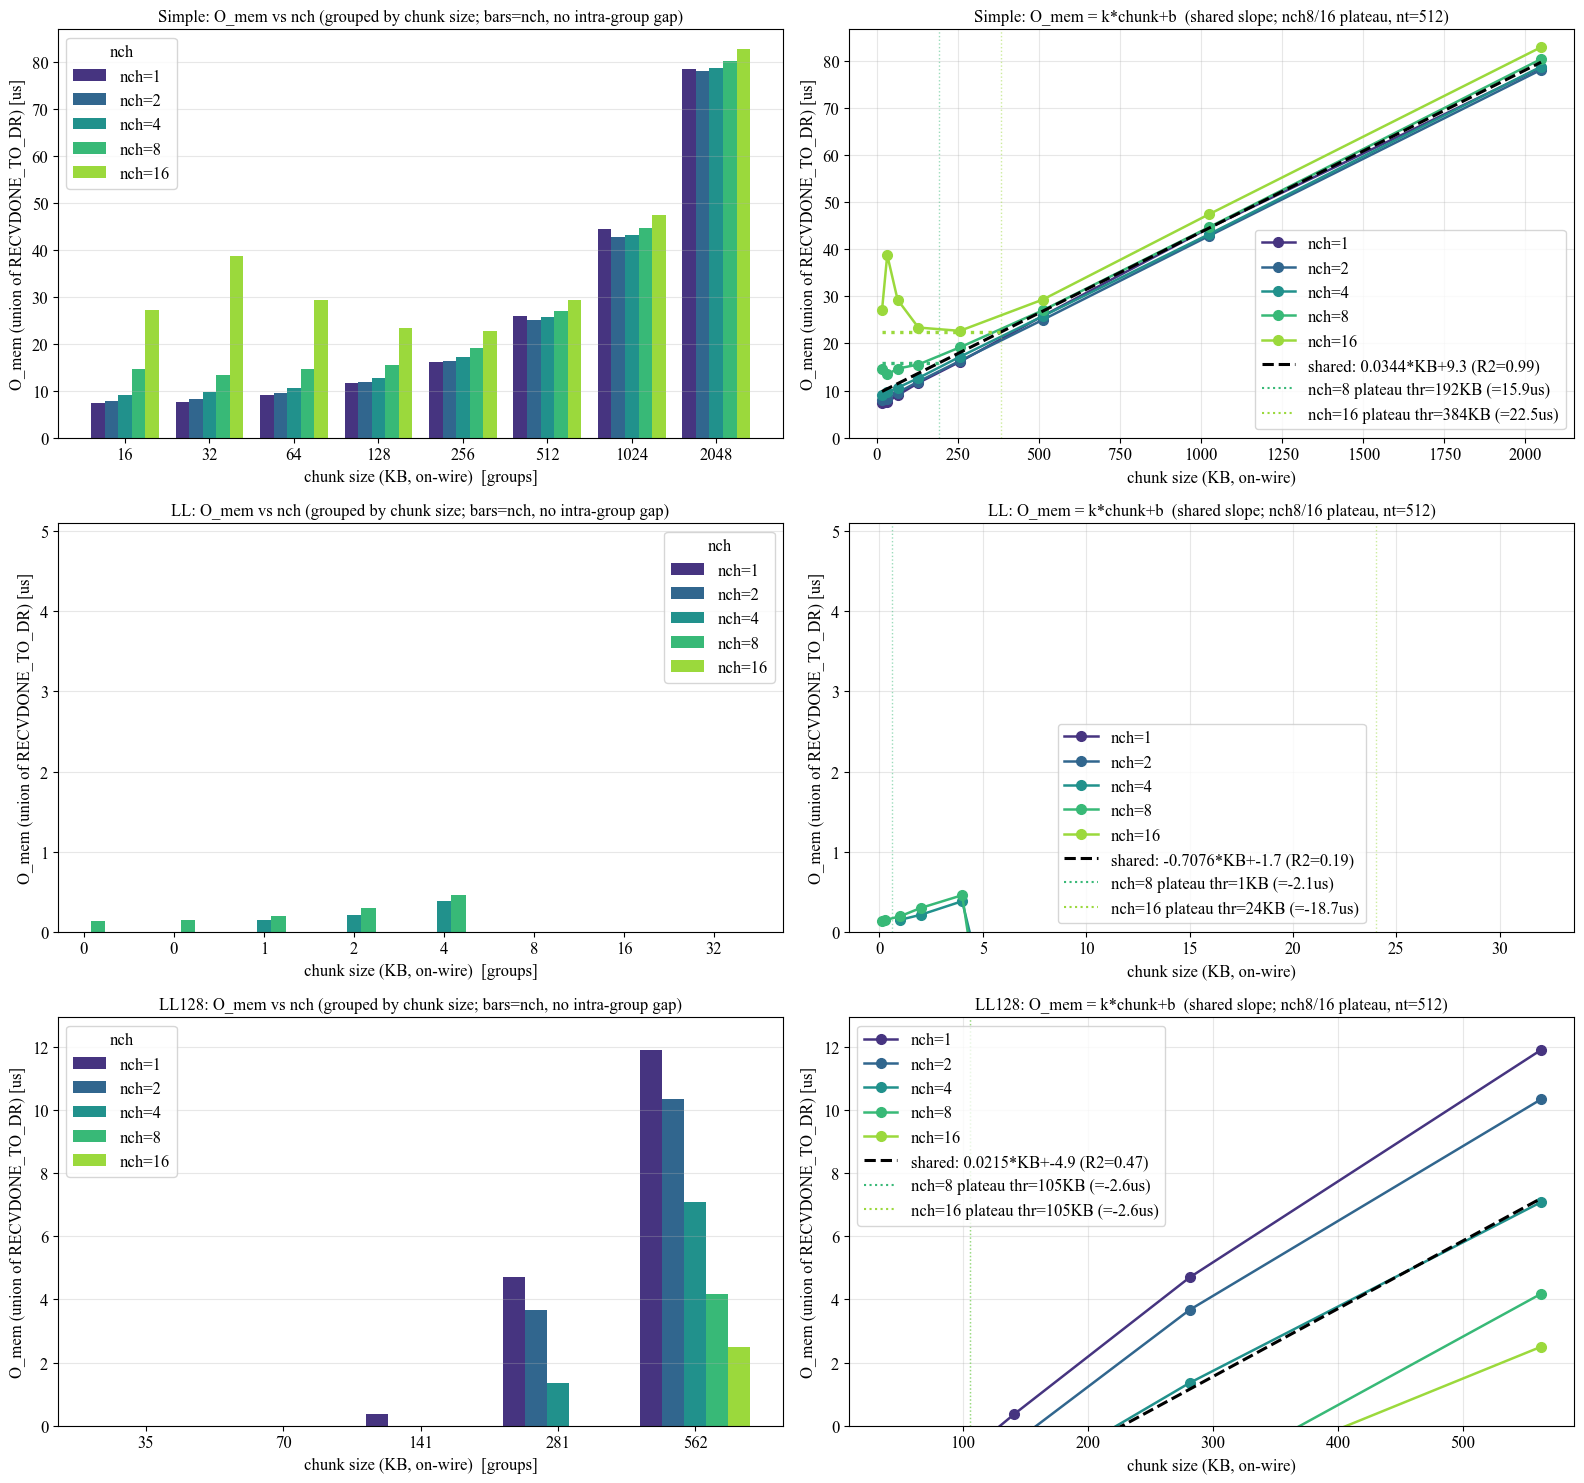

Saved: fig2_Gmem_threads.png

Simple O_mem (union) by chunk_KB x nch:
nch         1     2     4     8     16
chunk_KB                              
16.0       7.3   7.9   9.1  14.5  27.1
32.0       7.6   8.3   9.6  13.4  38.8
64.0       9.0   9.6  10.6  14.7  29.3
128.0     11.6  11.9  12.7  15.5  23.4
256.0     16.1  16.3  17.2  19.2  22.7
512.0     25.8  25.0  25.8  27.0  29.3
1024.0    44.5  42.8  43.2  44.7  47.4
2048.0    78.5  78.1  78.7  80.3  82.9

LL O_mem (union) by chunk_KB x nch:
nch        1    2    4     8     16
chunk_KB                           
0.125     NaN  NaN  NaN   0.1 -12.2
0.250     NaN  NaN  NaN   0.1  -9.1
1.000    -0.4 -0.2  0.1   0.2 -10.0
2.000    -0.3 -0.3  0.2   0.3  -9.5
4.000    -0.7 -0.1  0.4   0.5 -11.3
8.000    -3.0 -3.1 -3.9  -6.4 -18.3
16.000   -4.0 -4.1 -5.5 -10.9 -50.5
32.000   -2.9 -3.7 -5.9 -13.9 -92.4

LL128 O_mem (union) by chunk_KB x nch:
nch          1     2    4    8    16
chunk_KB                            
35.15625   -2.4  -2.5 -2.9 -4

In [633]:
import re
protos = ['Simple', 'LL', 'LL128']
colors = {'Simple': '#2E86C1', 'LL': '#E74C3C', 'LL128': '#27AE60'}
NT = 512

def buf_bytes(s):
    m = re.match(r'([\d.]+)\s*([KMG]?B)', s.strip())
    return float(m.group(1)) * {'B':1, 'KB':1024, 'MB':1024**2, 'GB':1024**3}[m.group(2)]

def chunk_size_KB(proto, buffsize):
    # on-wire bytes: Simple=buffsize/4 ; LL=buffsize/8/2 ; LL128=buffsize/8*15/16
    b = buf_bytes(buffsize)
    if proto == 'Simple': return (b/4)/1024
    elif proto == 'LL':   return ((b/8)/2)/1024
    else:                 return ((b/8)*15.0/16.0)/1024

# O_mem via UNION method (O_mem_model_us), nt=512
d = param_df[(param_df.nthreads == NT)].copy()
d['chunk_KB'] = d.apply(lambda r: chunk_size_KB(r.protocol, r.buffsize), axis=1)
nch_all = sorted(d.nch.unique())
nch_cmap = {n: plt.cm.viridis(0.15 + 0.7*i/max(1,len(nch_all)-1)) for i, n in enumerate(nch_all)}

# One ROW per protocol: [left] O_mem vs nch as grouped BARS (group=chunk size, bars=nch, no gap
# within a group), [right] O_mem vs chunk size as LINES (one per nch).
fig, axes = plt.subplots(len(protos), 2, figsize=(16, 5.0*len(protos)))
if len(protos) == 1:
    axes = axes.reshape(1, 2)

for r, p in enumerate(protos):
    dp = d[d.protocol == p]
    # chunk sizes (groups), sorted; and nch present
    cks = sorted(dp.chunk_KB.round(1).unique())
    nchs = sorted(dp.nch.unique())
    n_b = len(nchs)

    # ---------- LEFT: grouped bar, group=chunk size, bar=nch (no intra-group gap) ----------
    ax = axes[r, 0]
    group_w = 0.8                      # fraction of unit slot used by a group (gap between groups)
    bar_w = group_w / max(1, n_b)      # bars fill the group with NO gap between them
    x0 = np.arange(len(cks))           # one slot per chunk-size group
    for j, n in enumerate(nchs):
        ys = []
        for ck in cks:
            s = dp[(dp.nch == n) & (dp.chunk_KB.round(1) == ck)]
            ys.append(s.O_mem_model_us.mean() if len(s) else np.nan)
        xpos = x0 - group_w/2 + bar_w*(j + 0.5)
        ax.bar(xpos, ys, width=bar_w, color=nch_cmap[n], edgecolor='none', label=f'nch={n}')
    ax.set_xticks(x0); ax.set_xticklabels([f'{c:.0f}' for c in cks])
    ax.set_xlabel('chunk size (KB, on-wire)  [groups]'); ax.set_ylabel('O_mem (union of RECVDONE_TO_DR) [us]')
    ax.set_ylim(0, None)
    ax.set_title(f'{p}: O_mem vs nch (grouped by chunk size; bars=nch, no intra-group gap)')
    ax.legend(fontsize=FS, title='nch'); ax.grid(alpha=0.3, axis='y')

    # ---------- RIGHT: line, O_mem vs chunk size, one line per nch + O_MEM_FIT overlay ----------
    ax = axes[r, 1]
    for n in nchs:
        s = dp[dp.nch == n].sort_values('chunk_KB')
        if len(s) < 1: continue
        ax.plot(s.chunk_KB, s.O_mem_model_us, 'o-', color=nch_cmap[n], ms=7, lw=1.8, label=f'nch={n}')
    # ---- O_mem fit: O_mem = k*chunk_KB + b, shared slope k,b from LARGE-chunk pool (>= BIG_KB);
    #      nch 8/16 have a low-chunk PLATEAU held at the line value at an auto-searched threshold ----
    BIG_KB = 256.0
    _big = dp[dp.chunk_KB >= BIG_KB]
    _f = ols(_big.chunk_KB.values, _big.O_mem_model_us.values) if len(_big) >= 2 else ols(dp.chunk_KB.values, dp.O_mem_model_us.values)
    _k, _b = _f['b'], _f['a']
    _xs_line = np.linspace(dp.chunk_KB.min(), dp.chunk_KB.max(), 100)
    ax.plot(_xs_line, _k*_xs_line + _b, 'k--', lw=2.2, zorder=5,
            label=f'shared: {_k:.4f}*KB+{_b:.1f} (R2={_f["r2"]:.2f})')
    for n in (8, 16):
        if n not in nchs: continue
        s = dp[dp.nch == n].sort_values('chunk_KB'); xs = s.chunk_KB.values; ys = s.O_mem_model_us.values
        best = None
        for ki in range(2, len(xs)):
            thr = (xs[ki-1]+xs[ki])/2.0; c = _k*thr + _b
            sse = float(np.sum((ys[:ki]-c)**2) + np.sum((ys[ki:]-(_k*xs[ki:]+_b))**2))
            if best is None or sse < best[0]: best = (sse, thr, c)
        if best is not None:
            _sse, _thr, _c = best
            ax.hlines(_c, dp.chunk_KB.min(), _thr, color=nch_cmap[n], ls=':', lw=2.4, zorder=6)
            ax.axvline(_thr, color=nch_cmap[n], ls=':', lw=1.0, alpha=0.5)
            ax.plot([], [], ':', color=nch_cmap[n], label=f'nch={n} plateau thr={_thr:.0f}KB (={_c:.1f}us)')
    ax.set_xlabel('chunk size (KB, on-wire)'); ax.set_ylabel('O_mem (union of RECVDONE_TO_DR) [us]'); ax.set_ylim(0, None)
    ax.set_title(f'{p}: O_mem = k*chunk+b  (shared slope; nch8/16 plateau, nt={NT})')
    ax.legend(fontsize=FS); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('fig2_Gmem_threads.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig2_Gmem_threads.png')
for p in protos:
    print(f'\n{p} O_mem (union) by chunk_KB x nch:')
    print(d[d.protocol==p].pivot_table(index='chunk_KB', columns='nch', values='O_mem_model_us').round(1).to_string())


## Figure 3 — Claim 3: `O_round` is a real periodic drain for Simple, ~0 for LL/LL128

**Method: one-sample t-test of `O_round_excess` (round-boundary interval minus steady inter-chunk interval) against 0, per protocol.**

If Simple has a genuine periodic pipeline drain, its `O_round_excess` should be significantly `> 0`. If LL/LL128 have no drain, theirs should be statistically indistinguishable from 0.

protocol  n  mean_excess_us  median_us         t       p_vs_0
  Simple 40      101.509460  48.453623  5.322262 1.024846e-07
      LL 33       30.625532  19.060959  4.750111 2.033050e-06
   LL128 24       23.322359  21.733615 17.459495 0.000000e+00


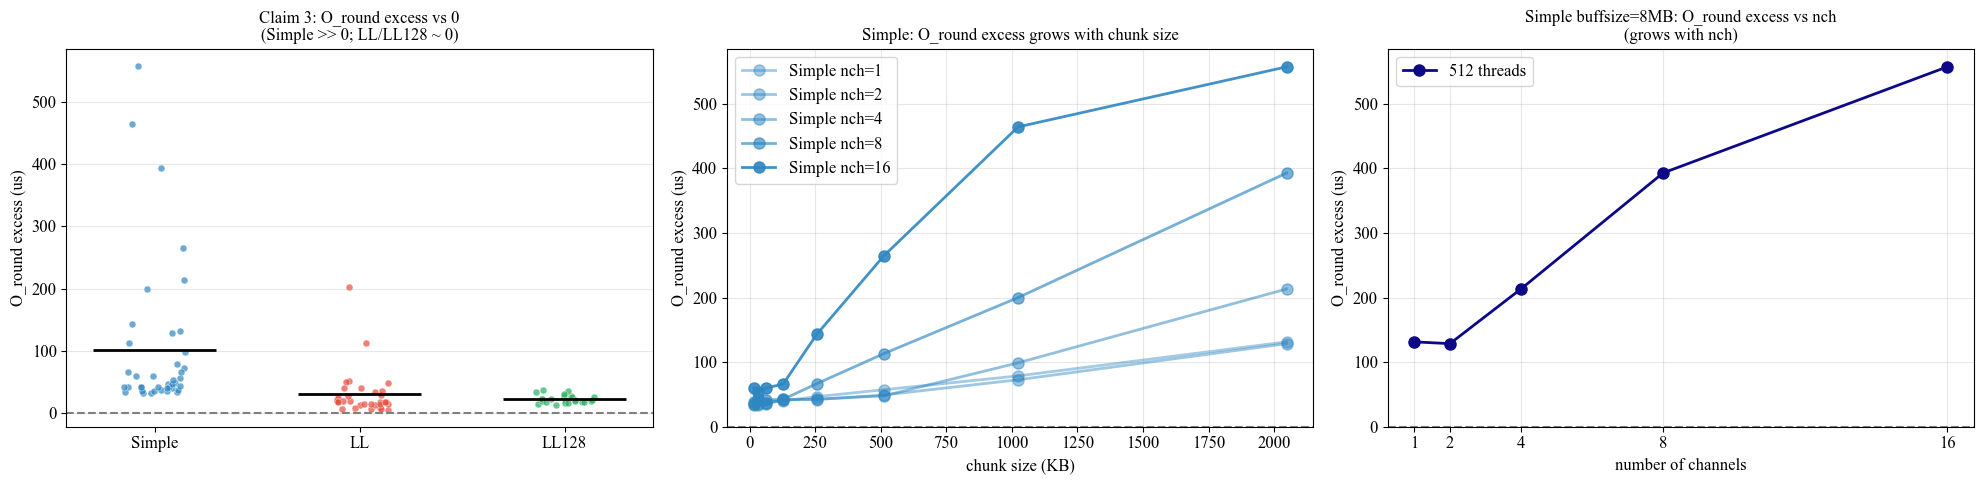

Saved: fig3_Oround.png


In [634]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
# left: O_round_excess distribution per protocol
ax = axes[0]
test_rows = []
for i, p in enumerate(protos):
    v = param_df[(param_df.protocol == p)]['O_round_excess_us'].dropna().values
    t, n, pval = one_sample_t(v, 0.0)
    test_rows.append({'protocol': p, 'n': n, 'mean_excess_us': v.mean(), 'median_us': np.median(v),
                      't': t, 'p_vs_0': pval})
    jit = (np.random.default_rng(i+9).random(len(v))-0.5)*0.3
    ax.scatter(np.full(len(v), i)+jit, v, color=colors[p], s=25, alpha=0.7, edgecolor='w', linewidth=0.4)
    ax.hlines(v.mean(), i-0.3, i+0.3, color='k', lw=2)
ax.axhline(0, color='gray', ls='--')
ax.set_xticks(range(len(protos))); ax.set_xticklabels(protos)
ax.set_ylabel('O_round excess (us)')
ax.set_title('Claim 3: O_round excess vs 0\n(Simple >> 0; LL/LL128 ~ 0)')
ax.grid(alpha=0.3, axis='y')
tt = pd.DataFrame(test_rows)
print(tt.to_string(index=False))

# right: Simple only, O_round excess vs chunk size (chunk_size = buffsize/4), linear x-axis
import re
def _buf_bytes(s):
    m = re.match(r'([\d.]+)\s*([KMG]?B)', s.strip())
    return float(m.group(1)) * {'B':1, 'KB':1024, 'MB':1024**2, 'GB':1024**3}[m.group(2)]
ax = axes[1]
sim = param_df[(param_df.protocol=='Simple') & (param_df.nthreads==512)].copy()
sim['chunk_KB'] = sim.buffsize.apply(lambda b: _buf_bytes(b)/4/1024)   # Simple: buffsize/4
for nch in sorted(sim.nch.unique()):
    dd = sim[sim.nch==nch].dropna(subset=['O_round_excess_us']).sort_values('chunk_KB')
    if len(dd):
        ax.plot(dd.chunk_KB, dd.O_round_excess_us, 'o-', color=colors['Simple'],
                ms=8, lw=2, alpha=min(1.0, 0.4+0.5*nch/16), label=f'Simple nch={nch}')
ax.axhline(0, color='gray', ls='--')
ax.set_xlabel('chunk size (KB)'); ax.set_ylabel('O_round excess (us)')
ax.set_title('Simple: O_round excess grows with chunk size')
ax.legend(fontsize=FS); ax.grid(alpha=0.3); ax.set_ylim(0, None)
# third: Simple buffsize=8MB, O_round excess vs nch (one line per nthreads)
ax = axes[2]
sim8 = param_df[(param_df.protocol=='Simple') & (param_df.buffsize=='8MB')].dropna(subset=['O_round_excess_us'])
nthreads_list = sorted(sim8.nthreads.unique())
nt_cmap = {nt: plt.cm.plasma(i/max(1,len(nthreads_list)-1)*0.85) for i, nt in enumerate(nthreads_list)}
for nt in nthreads_list:
    s = sim8[sim8.nthreads==nt].sort_values('nch')
    if len(s):
        ax.plot(s.nch, s.O_round_excess_us, 'o-', color=nt_cmap[nt], ms=8, lw=2, label=f'{nt} threads')
ax.axhline(0, color='gray', ls='--')
ax.set_xticks(sorted(sim8.nch.unique())); ax.set_xticklabels([int(x) for x in sorted(sim8.nch.unique())])
ax.set_xlabel('number of channels'); ax.set_ylabel('O_round excess (us)')
ax.set_title('Simple buffsize=8MB: O_round excess vs nch\n(grows with nch)')
ax.legend(fontsize=FS); ax.grid(alpha=0.3); ax.set_ylim(0, None)

plt.tight_layout(); plt.savefig('fig3_Oround.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig3_Oround.png')

## Summary of statistical evidence

| Claim | Statistic | Verdict |
|-------|-----------|---------|
| 1. `O_net` vs `nch` (fluid model) | recovered-BW fixed point converges to 48.75; O_net rises monotonically with `nch` | **supported** |
| 2. `G_mem` from T6-interval union (channel 0) | union coverage / #chunks; per-protocol G_mem stable | **supported** |
| 3. `O_round` real for Simple, ~0 for LL/LL128 | one-sample t-test: Simple mean >> 0 (p<<0.01), LL/LL128 indistinguishable from 0 | **supported** |

In [635]:
# ============================================================
# Export calibrated parameters -> ring_params.json
# Consumed by ../../p5en-allreduce-0x7/p5en-allreduce-0x7-realistic.ipynb
# Run after the three figure cells so param_df / ols / STAT exist.
# ============================================================
import json as _json, re as _re

def _buf_bytes(s):
    m = _re.match(r'([\d.]+)\s*([KMG]?B)', s.strip())
    return float(m.group(1)) * {'B':1, 'KB':1024, 'MB':1024**2, 'GB':1024**3}[m.group(2)]

def _chunk_bytes(proto, buffsize):
    b = _buf_bytes(buffsize)
    return b/4 if proto == 'Simple' else b/8   # Simple: buffsize/4 ; LL,LL128: buffsize/8 (= slice_size)

def _slice_bytes(proto, buffsize):
    # SLICE bytes (the quantity the realistic model keys O_net on):
    #   NCCL Simple: chunk = buffsize/2, slice = chunk/2 = buffsize/4
    #   LL/LL128: slice = chunk = buffsize/8 (with on-wire proto factor)
    #   Simple: buffsize/4 ; LL: (buffsize/8)/2 ; LL128: (buffsize/8)*15/16
    b = _buf_bytes(buffsize)
    if proto == 'Simple': return b/4
    elif proto == 'LL':   return (b/8)/2
    else:                 return (b/8)*15.0/16.0

_pdf = param_df.copy()
_pdf['chunk_B'] = _pdf.apply(lambda r: _chunk_bytes(r.protocol, r.buffsize), axis=1)   # slice_size convention
_pdf['slice_B']  = _pdf.apply(lambda r: _slice_bytes(r.protocol, r.buffsize), axis=1)     # on-wire (O_net model)
protos = ['Simple', 'LL', 'LL128']

SEL_BUF_FIT = {'Simple': '8MB', 'LL': '512KB', 'LL128': '4800KB'}
NT_FIT = 512
# exclude the largest buffsize per protocol (chunk > representative cap) from O_net anchors/fits
EXCLUDE_BUF = {'Simple': {'16MB'}, 'LL': {'1MB'}, 'LL128': {'9600KB'}}

_dfit = _pdf[(_pdf.nthreads == NT_FIT)].dropna(subset=['O_net_gauge_us']).copy()
_dfit = _dfit[~_dfit.apply(lambda r: r.buffsize in EXCLUDE_BUF.get(r.protocol, set()), axis=1)]
_dfit['slice_MB'] = _dfit['slice_B'] / (1024**2)

# ---- O_net LOOKUP ANCHORS (PRIMARY): measured O_net at each (proto, nch, on-wire chunk) ----
#   Used by realistic model as a table + piecewise-linear interpolation in chunk (per nch):
#     - chunk at/above the largest anchor (representative cap) -> that anchor's O_net (big message)
#     - chunk between two anchors -> linear interpolation
#     - chunk at/below smallest anchor -> smallest anchor's O_net (clamp; small msg not measured smaller)
#   Anchors are the MEASURED fluid O_net (zero fit loss on measured points). Keys: nch -> [[wire_bytes, O_net_us], ...]
O_NET_ANCHORS = {}
for p in protos:
    sp = _dfit[_dfit.protocol == p]
    O_NET_ANCHORS[p] = {}
    for n in sorted(sp.nch.unique()):
        pts = sp[sp.nch == n].sort_values('slice_B')
        O_NET_ANCHORS[p][int(n)] = [[int(round(r.slice_B)), round(float(r.O_net_gauge_us), 4)]
                                     for _, r in pts.iterrows()]

# ---- O_net 2-D PIECEWISE model (secondary / reference): O_net = O_fixed + beta*max(0,nch-2)^gamma*slice_MB ----
#   Kept as a smooth summary of the (nch, chunk) trend; realistic uses ANCHORS, not this.
O_NET_PIECEWISE = {}
for p in protos:
    s = _dfit[_dfit.protocol == p]
    O_fixed = float(s[s.nch <= 2].O_net_gauge_us.mean())
    comp = s[s.nch >= 4]
    _ex = (comp.nch.values - 2.0); _ck = comp.slice_MB.values
    _yc = comp.O_net_gauge_us.values - O_fixed
    _yall = s.O_net_gauge_us.values
    _exall = np.maximum(0.0, s.nch.values - 2.0); _ckall = s.slice_MB.values
    _st = np.sum((_yall - _yall.mean())**2)
    best = None
    for _gm in np.linspace(1.0, 2.0, 101):
        _X = (_ex**_gm) * _ck
        _bb = float(np.sum(_X*_yc) / np.sum(_X*_X)) if np.sum(_X*_X) > 0 else 0.0
        _yh = O_fixed + _bb * (_exall**_gm) * _ckall
        _r2 = 1 - np.sum((_yall - _yh)**2)/_st
        if best is None or _r2 > best[0]:
            best = (_r2, _gm, _bb)
    _r2, gamma, beta = best
    O_NET_PIECEWISE[p] = {'O_fixed_us': round(O_fixed, 4),
                          'beta_us_per_MB': round(beta, 4),
                          'gamma': round(gamma, 4),
                          'R2': round(_r2, 4)}

# representative cap chunk (on-wire bytes) at each protocol's rep buffsize -- "big message" O_net
O_NET_CAP_BYTES = {p: int(round(_slice_bytes(p, SEL_BUF_FIT[p]))) for p in protos}

# (3) G_mem: reduce (mem-copy) bandwidth, measured on CHANNEL 0 only.
#   Per config, take channel 0's chunks; each chunk's reduce occupies [abs_rx_done, abs_rx_done+RECVDONE_TO_DR].
#   Build the UNION of these intervals (a gap between chunk i and i+1 -> both RECVDONE_TO_DR counted in full;
#   an overlap -> the overlapping part counted once). per-chunk mem time = union_len / (#chunks with RECVDONE_TO_DR).
#   G_mem = on-wire chunk bytes / per-chunk mem time.  Averaged over nch=1, nthreads>=256 configs.
def _ch0_union_per_chunk_us(cfg):
    sg = sorted(cfg['sends'], key=lambda s: s['channel'])[0]   # channel 0
    ivs = []
    for x in sg['chunks']:
        if (x.get('abs_rx_done') is not None and x.get('recvdone_to_dr') is not None
                and (x.get('recvdone_to_dr_n') or 0) >= 50):   # drop low-sample (unreliable median) chunks
            st = x['abs_rx_done'] * 1e3
            ivs.append((st, st + x['recvdone_to_dr'] * 1e3))
    if not ivs:
        return None
    ivs.sort()
    union = 0.0; cur_s, cur_e = ivs[0]
    for st, en in ivs[1:]:
        if st > cur_e:                      # gap -> start a fresh interval (both RECVDONE_TO_DR counted)
            union += cur_e - cur_s; cur_s, cur_e = st, en
        else:                               # overlap -> extend, counting the overlap once
            cur_e = max(cur_e, en)
    union += cur_e - cur_s
    return union / len(ivs)                 # divide by number of chunks

def _wire_of(cfg):
    return _slice_bytes(cfg['protocol'], cfg['buffsize'])

# ---- O_mem = k*slice_KB + b  (LINEAR with intercept, from the O_mem-vs-slice scatter) ----
#   Shared slope k & intercept b: fit the LARGE-chunk points (slice_KB >= O_MEM_BIG_KB) pooled
#   across ALL nch (they collapse onto one line there). nch 1/2/4 use this line over the whole
#   range. nch 8/16 have a low-chunk PLATEAU: below an auto-searched per-nch threshold O_mem is a
#   CONSTANT equal to the shared line's value AT the threshold (k*thr+b) -> continuous join, then
#   the shared line above. G_MEM_GBS kept for reference/back-compat as 1/k (GB/s).
O_MEM_BIG_KB = 256.0                          # "large chunk" cutoff for the shared-slope pool
_omem_src = param_df[param_df.nthreads == 512].copy()
_omem_src['skb'] = _omem_src.apply(lambda r: _slice_bytes(r.protocol, r.buffsize)/1024.0, axis=1)

O_MEM_FIT = {}
G_MEM_GBS = {}
for p in protos:
    dp = _omem_src[_omem_src.protocol == p].dropna(subset=['O_mem_model_us'])
    big = dp[dp.skb >= O_MEM_BIG_KB]
    if len(big) >= 2:
        _f = ols(big.skb.values, big.O_mem_model_us.values)
        k = _f['b']; b = _f['a']; r2 = _f['r2']
    else:                                     # too few large points -> pool everything
        _f = ols(dp.skb.values, dp.O_mem_model_us.values); k = _f['b']; b = _f['a']; r2 = _f['r2']
    # per-nch low-chunk plateau threshold (only nch 8/16); flat const = k*thr + b (continuous)
    thr_by_nch = {}
    for nch in sorted(dp.nch.unique()):
        if int(nch) not in (8, 16):
            continue
        s = dp[dp.nch == nch].sort_values('skb'); xs = s.skb.values; ys = s.O_mem_model_us.values
        best = None
        for ki in range(2, len(xs)):          # lo = xs[:ki] (>=2 pts), hi = xs[ki:] on shared line
            thr = (xs[ki-1] + xs[ki]) / 2.0; c = k*thr + b
            sse = float(np.sum((ys[:ki]-c)**2) + np.sum((ys[ki:]-(k*xs[ki:]+b))**2))
            if best is None or sse < best[0]:
                best = (sse, thr)
        if best is not None:
            thr_by_nch[int(nch)] = round(best[1], 1)
    O_MEM_FIT[p] = {'k_us_per_KB': round(k, 6), 'b_us': round(b, 4), 'R2': round(r2, 4),
                    'big_chunk_KB': O_MEM_BIG_KB, 'nch_plateau_thr_KB': thr_by_nch}
    G_MEM_GBS[p] = round(1024.0/k/1e3, 4) if k > 0 else float('nan')  # bytes/us = 1024/k (k is us/KB) -> GB/s

# (4) O_round: 0 for LL/LL128; Simple bilinear O_round = C + K*(slice_MB*nch)
#   Uses O_round_raw (round-boundary send interval atx[24]-atx[23]) directly -- NO subtraction of
#   the chunk transfer share chunk/(G/nch); the realistic Case model handles bandwidth separately.
_sim = _pdf[(_pdf.protocol == 'Simple') & (_pdf.nthreads == 512)].dropna(subset=['O_round_raw_us']).copy()
_sim['x'] = _sim.chunk_B / (1024**2) * _sim.nch
_fr = ols(_sim.x.values, _sim.O_round_raw_us.values)
O_ROUND_C = round(_fr['a'], 4); O_ROUND_K = round(_fr['b'], 4); OROUND_R2 = round(_fr['r2'], 4)

# ---- o_net_eff LINEAR fit per (proto, nch): o_net_eff = intercept + slope*chunk_KB ----
#   From fig2 (o_net_eff = o_net / k_eff_o_net; pipeline-exposed net overhead per chunk).
#   Realistic use: o_net_eff(proto,nch,chunk) = intercept + slope*(chunk_bytes/1024),
#   then o_net_total = nchunks * o_net_eff  (feeds T = 2L + bwterm + o_net_total).
O_NET_RAW_LINFIT = {}   # single line per (proto,nch): raw O_net (before /overlap) = intercept + slope*chunk_KB
for _r in onet_raw_fit_rows:
    O_NET_RAW_LINFIT.setdefault(_r['protocol'], {})[int(_r['nch'])] = {
        'intercept_us': _r['intercept_us'], 'slope_us_per_KB': _r['slope_us_per_KB'], 'R2': _r['R2']}
O_NET_EFF_LINFIT = {}   # two-segment per (proto, nch): flat constant below breakpoint, line above
for _r in onet_eff_fit_rows:
    O_NET_EFF_LINFIT.setdefault(_r['protocol'], {})[int(_r['nch'])] = {
        'breakpoint_KB': _r['breakpoint_KB'],           # split point (slice_KB); None -> single line
        'lo_const_us': _r['lo_const_us'],               # slice_KB <  breakpoint -> this CONSTANT (mean)
        'hi_intercept_us': _r['hi_intercept_us'],       # slice_KB >= breakpoint -> intercept + slope*slice_KB
        'hi_slope_us_per_KB': _r['hi_slope_us_per_KB'],
        'hi_R2': _r['hi_R2'],
    }

_FLUID_WIN_STR = 'Simple c3-c9, LL c12-c15, LL128 c7-c11'
params = {
    'note': 'Calibrated from ring_param_extraction.ipynb. Overhead helpers take SLICE_SIZE (bytes). '
            'chunk convention: Simple=buffsize/4, LL/LL128=buffsize/8. '
            f'O_net = FLUID recovered-bandwidth model, median over per-protocol steady window ({_FLUID_WIN_STR}).',
    'STAT': STAT,
    'n_configs': int(len(param_df)),
    'O_NET_METHOD': ('fluid (recovered-bandwidth fixed point), per-protocol steady window median '
                     f'({_FLUID_WIN_STR}). PRIMARY use: O_NET_ANCHORS table + piecewise-linear interp in '
                     'on-wire chunk per nch (clamp at both ends); measured points used verbatim (no fit loss). '
                     'O_NET_PIECEWISE is a smooth 2-D summary only. wire bytes: Simple=buf/4, LL=buf/8/2, LL128=buf/8*15/16.'),
    'O_NET_ANCHORS': O_NET_ANCHORS,         # {proto: {nch: [[wire_bytes, O_net_us], ...]}} -- PRIMARY (table+interp)
    'O_NET_CAP_BYTES': O_NET_CAP_BYTES,     # on-wire chunk at rep buffsize (big-message O_net anchor)
    'O_NET_PIECEWISE': O_NET_PIECEWISE,     # {proto: {O_fixed_us, beta_us_per_MB, gamma, R2}} -- smooth summary (ref)
    'O_NET_EFF_LINFIT': O_NET_EFF_LINFIT,
    'O_NET_RAW_LINFIT': O_NET_RAW_LINFIT,   # {proto:{nch:{intercept_us,slope_us_per_KB,R2,excluded_small_chunks}}} o_net_eff=a+b*chunkKB
    'NIC_BW_DUAL_bytes_us': NIC_BW_DUAL,
    'O_NET_SEL_BUF': SEL_BUF_FIT,           # representative buffsize per protocol
    'O_NET_NT_FIT': NT_FIT,
    'O_NET_EXCLUDE_BUF': {k: sorted(v) for k, v in EXCLUDE_BUF.items()},
    'G_MEM_GBS': G_MEM_GBS,
    'O_MEM_FIT': O_MEM_FIT,
    'O_ROUND_C_us': O_ROUND_C,
    'O_ROUND_K_us_per_MBch': O_ROUND_K,
    'O_ROUND_R2': OROUND_R2,
}
with open('ring_params.json', 'w') as _f:
    _json.dump(params, _f, indent=2)
print("Exported ring_params.json:")
print(_json.dumps(params, indent=2))


Exported ring_params.json:
{
  "note": "Calibrated from ring_param_extraction.ipynb. Overhead helpers take SLICE_SIZE (bytes). chunk convention: Simple=buffsize/4, LL/LL128=buffsize/8. O_net = FLUID recovered-bandwidth model, median over per-protocol steady window (Simple c3-c9, LL c12-c15, LL128 c7-c11).",
  "STAT": "med",
  "n_configs": 99,
  "O_NET_METHOD": "fluid (recovered-bandwidth fixed point), per-protocol steady window median (Simple c3-c9, LL c12-c15, LL128 c7-c11). PRIMARY use: O_NET_ANCHORS table + piecewise-linear interp in on-wire chunk per nch (clamp at both ends); measured points used verbatim (no fit loss). O_NET_PIECEWISE is a smooth 2-D summary only. wire bytes: Simple=buf/4, LL=buf/8/2, LL128=buf/8*15/16.",
  "O_NET_ANCHORS": {
    "Simple": {
      "1": [
        [
          16384,
          4.521
        ],
        [
          32768,
          7.459
        ],
        [
          65536,
          10.2755
        ],
        [
          131072,
          13.382
    